<a href="https://colab.research.google.com/github/Minwoo5/BDAI-13th-Cohort/blob/main/ML1/Lecture/260902_%E1%84%86%E1%85%A5%E1%84%89%E1%85%B5%E1%86%AB%E1%84%85%E1%85%A5%E1%84%82%E1%85%B5%E1%86%BC_%E1%84%8B%E1%85%B5%E1%86%B8%E1%84%86%E1%85%AE%E1%86%AB_OT_%E1%84%92%E1%85%AC%E1%84%80%E1%85%B1%E1%84%8B%E1%85%AA_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%85%E1%85%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 입문 OT — 예측이라는 문제를 수학으로 적는 법

## Principles of Statistical Learning (1) : Regression Problem, Loss, Risk, Optimal Rule

첫 시간입니다. 오늘은 모델을 많이 배우지 않습니다.

앞의 세 장은 머신러닝을 한 번도 안 다뤄본 사람을 위한 도입입니다. 코드를 몰라도 따라올 수 있습니다.
그 뒤부터는 앞으로 배울 모든 모델이 공통으로 깔고 있는 **문장 하나**를 이해하는 데 시간을 씁니다.

$$\hat{f} = \arg\min_{f \in \mathcal{F}} \; \frac{1}{n}\sum_{i=1}^{n} \ell\big(y_i,\, f(x_i)\big)$$

선형회귀도, 랜덤포레스트도, 딥러닝도 전부 이 식의 변주입니다.
$\ell$ 을 무엇으로 쓸지, $\mathcal{F}$ 를 어디까지 넓힐지, $\arg\min$ 을 어떻게 풀지가 다를 뿐입니다.

오늘 끝나면 이 식의 기호 네 개 $(\ell,\ \mathcal{F},\ n,\ \hat f)$ 를 각자 말로 설명할 수 있어야 합니다.

---

### OT

**1 — 머신러닝이 무엇인지부터**

| # | 내용 |
|---|------|
| 1 | 머신러닝이란 무엇인가 / AI·ML·DL의 관계 |
| 2 | 지도학습 · 비지도학습 · 강화학습 |
| 3 | 데이터 용어, 데이터를 나누는 이유, 프로젝트의 흐름 |

**2 — 예측 문제를 수학으로 적기**

| # | 내용 | 핵심 질문 |
|---|------|-----------|
| 4 | 지도학습을 기호로 적기 (회귀와 분류) | 회귀와 분류는 무엇이 다른가 |
| 5 | 예측함수 $f$ 를 고른다는 것 | 좋은 $f$ 를 눈으로 고를 수 있는가 |
| 6 | 손실 Loss $\ell(y, f(x))$ | 틀린 정도를 어떻게 숫자로 적을 것인가 |
| 7 | 위험도 Risk $R(f)$ | 손실과 위험도는 무엇이 다른가 |
| 8 | 최적 규칙 (Bayes rule) | 이론상 가장 좋은 예측은 무엇인가 |
| 9 | 경험적 위험 최소화 (ERM) | 그럼 우리는 실제로 무엇을 계산하는가 |

### 준비물

`numpy`, `pandas`, `matplotlib`, `scikit-learn` 네 개만 있으면 됩니다.
코드는 위에서부터 순서대로 실행하세요 (`Shift + Enter`). 수식이 안 보여도 그림과 숫자만 따라오면 됩니다.

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")


def set_korean_font():
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
                  "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP", "UnDotum"]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            return name
    return None


font = set_korean_font()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

print("한글 폰트:", font or "찾지 못함 → Colab이면 !apt-get install -y fonts-nanum 후 런타임 재시작")

FIGDIR = Path("figures_ml")
FIGDIR.mkdir(exist_ok=True)


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", dpi=140, bbox_inches="tight", facecolor="white")


C = {"blue": "#2F6FA8", "red": "#C0392B", "green": "#1E8449",
     "orange": "#E67E22", "gray": "#7F8C8D", "purple": "#7D3C98"}

rng = np.random.default_rng(42)

import sklearn
print("scikit-learn", sklearn.__version__)

한글 폰트: Noto Sans CJK JP
scikit-learn 1.8.0


# 제1부 — 머신러닝이 무엇인지부터

여기부터 3장까지는 코드를 몰라도 됩니다. 그림과 이야기로만 갑니다.
머신러닝을 처음 듣는 사람이 "아, 그런 거구나" 하고 넘어갈 수 있게 만드는 것이 이 부분의 목표입니다.

## 1. 머신러닝이란 무엇인가

컴퓨터에게 일을 시키는 방법은 원래 하나뿐이었습니다. **규칙을 사람이 전부 적어주는 것**입니다.

세금 계산기를 만든다고 합시다. 세율표가 정해져 있으니 조건문 몇 개면 끝납니다.
소득이 얼마 이상이면 몇 퍼센트, 공제는 얼마. 규칙이 명확하니 사람이 적으면 됩니다. 이런 문제에는 머신러닝이 필요 없습니다.

그런데 이런 일은 어떨까요.

- 사진을 보고 개인지 고양이인지 맞히기
- 메일을 보고 스팸인지 아닌지 판단하기
- 손글씨로 쓴 숫자 읽기

"고양이란 무엇인가"를 조건문으로 적어보라고 하면 아무도 못 적습니다.
귀가 뾰족하면? 접힌 고양이도 있습니다. 수염이 있으면? 사진에 안 보일 수도 있습니다.
사람은 고양이를 알아보지만, **그 규칙을 말로 설명하지는 못합니다.**

그래서 발상을 뒤집었습니다.
규칙을 적어주는 대신 **예시를 잔뜩 주고 규칙을 스스로 찾게 하는 것**, 이것이 머신러닝입니다.

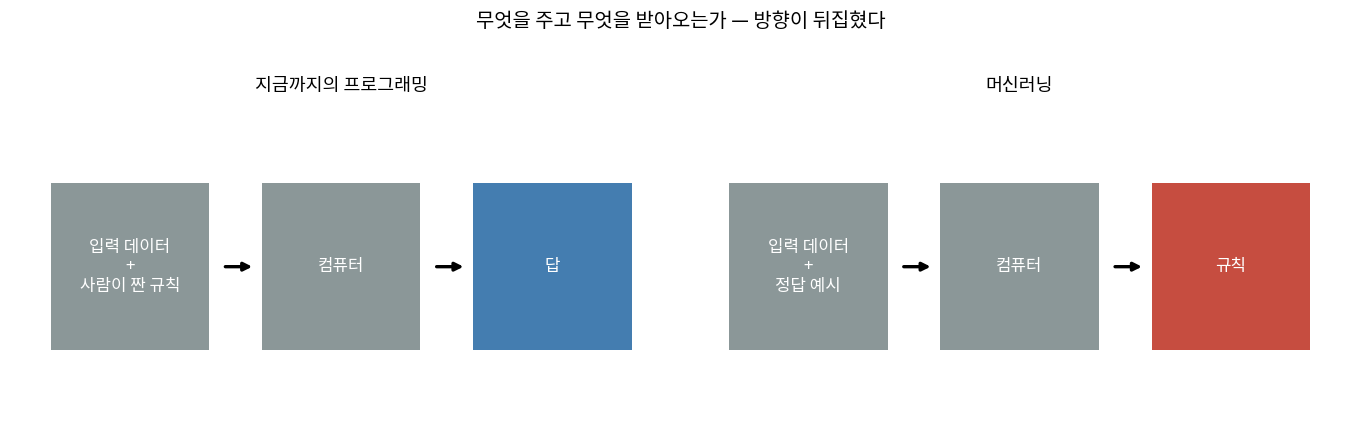

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))


def draw_flow(ax, blocks, title, color):
    for i, (label, kind) in enumerate(blocks):
        x0 = 0.06 + i * 0.32
        col = color if kind == "out" else C["gray"]
        ax.add_patch(plt.Rectangle((x0, .34), .24, .34, facecolor=col, alpha=.9))
        ax.text(x0 + .12, .51, label, ha="center", va="center", color="white", fontsize=11)
        if i < len(blocks) - 1:
            ax.annotate("", xy=(x0 + .31, .51), xytext=(x0 + .26, .51),
                        arrowprops=dict(arrowstyle="-|>", lw=2.2, color="black"))
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1); ax.set_ylim(.2, .85); ax.axis("off"); ax.grid(False)


draw_flow(axes[0], [("입력 데이터\n+\n사람이 짠 규칙", "in"), ("컴퓨터", "in"), ("답", "out")],
          "지금까지의 프로그래밍", C["blue"])
draw_flow(axes[1], [("입력 데이터\n+\n정답 예시", "in"), ("컴퓨터", "in"), ("규칙", "out")],
          "머신러닝", C["red"])
fig.suptitle("무엇을 주고 무엇을 받아오는가 — 방향이 뒤집혔다", y=1.02, fontsize=13)
fig.tight_layout()
save(fig, "A01_programming_vs_ml")
plt.show()

왼쪽은 규칙을 주고 답을 받습니다. 오른쪽은 **답을 주고 규칙을 받습니다.**
스팸 메일 10만 통과 정상 메일 10만 통을 주면서 "이 둘을 가르는 규칙을 네가 찾아라"라고 시키는 겁니다.

그래서 머신러닝에는 데이터가 반드시 필요합니다. 예시가 없으면 찾을 규칙도 없습니다.

### 인공지능, 머신러닝, 딥러닝은 어떻게 다른가

용어가 섞여 쓰이는데 관계는 단순합니다. 포함 관계입니다.

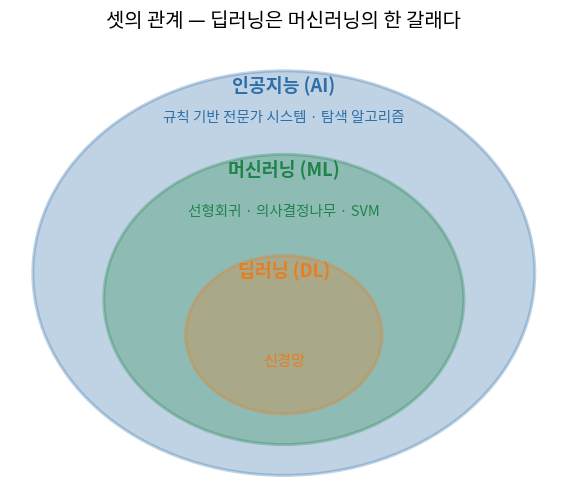

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
circles = [
    (0.5, 0.5, 0.46, C["blue"], "인공지능 (AI)", 0.90,
     "사람이 하던 지적 작업을\n기계가 수행하는 것 전부"),
    (0.5, 0.44, 0.33, C["green"], "머신러닝 (ML)", 0.70,
     "데이터에서 규칙을 학습"),
    (0.5, 0.36, 0.18, C["orange"], "딥러닝 (DL)", 0.45,
     "신경망을 깊게 쌓은 방법"),
]
for cx, cy, r, col, name, ty, desc in circles:
    ax.add_patch(plt.Circle((cx, cy), r, facecolor=col, alpha=.30, edgecolor=col, lw=2))
    ax.text(cx, cy + r - 0.045, name, ha="center", fontsize=12, weight="bold", color=col)

ax.text(0.5, 0.29, "신경망", ha="center", fontsize=10, color=C["orange"])
ax.text(0.5, 0.63, "선형회귀 · 의사결정나무 · SVM", ha="center", fontsize=9.5, color=C["green"])
ax.text(0.5, 0.845, "규칙 기반 전문가 시스템 · 탐색 알고리즘", ha="center", fontsize=9.5, color=C["blue"])
ax.set_xlim(0, 1); ax.set_ylim(0, 1.04); ax.axis("off"); ax.grid(False)
ax.set_title("셋의 관계 — 딥러닝은 머신러닝의 한 갈래다", fontsize=13)
save(fig, "A02_ai_ml_dl")
plt.show()

- **인공지능(AI)**: 가장 넓은 말입니다. 규칙을 직접 짜서 만든 옛날 전문가 시스템도 AI에 들어갑니다.
- **머신러닝(ML)**: 그중에서도 **데이터로부터 규칙을 배우는** 방법들입니다. 오늘 배울 내용이 여기입니다.
- **딥러닝(DL)**: 머신러닝 방법 중 신경망을 여러 층으로 쌓은 것입니다. ChatGPT 같은 것이 여기 속합니다.

딥러닝이 요즘 워낙 유명해서 "머신러닝 = 딥러닝"으로 오해하기 쉬운데, 실무에서 표 형태 데이터를 다룰 때는
여전히 선형회귀나 부스팅 같은 전통적인 방법이 더 잘 맞고 더 많이 쓰입니다.

### 이미 우리 주변에 있는 머신러닝

| 서비스 | 입력 | 출력 |
|---|---|---|
| 스팸 메일 분류 | 메일 제목·본문 | 스팸 / 정상 |
| 지도 앱 도착시간 | 출발지·도착지·시각·교통량 | 예상 소요시간(분) |
| 유튜브 추천 | 시청 기록 | 다음에 볼 영상 목록 |
| 얼굴 인식 잠금해제 | 카메라 이미지 | 본인 / 타인 |
| 카드사 이상거래 탐지 | 결제 금액·시각·가맹점 | 정상 / 의심 |

공통점이 보입니다. **무언가를 넣으면 무언가가 나옵니다.**
넣는 것을 입력 $X$, 나오는 것을 출력 $Y$ 라고 부르기로 하면, 머신러닝은 결국 $X$ 에서 $Y$ 로 가는 다리를 데이터로 놓는 일입니다.

## 2. 학습에는 세 가지 방식이 있다

머신러닝을 처음 배울 때 가장 먼저 외워야 할 분류입니다. **정답이 주어지느냐**로 갈립니다.

| | 지도학습 (Supervised) | 비지도학습 (Unsupervised) | 강화학습 (Reinforcement) |
|---|---|---|---|
| 데이터 | 입력 $X$ + **정답 $Y$** | 입력 $X$ 만 | 정답 없음, 대신 **보상** |
| 하는 일 | 정답을 맞히는 규칙 학습 | 데이터의 숨은 구조 발견 | 시행착오로 좋은 행동 학습 |
| 예시 | 집값 예측, 스팸 분류, 질병 진단 | 고객 세분화, 이상 탐지, 차원 축소 | 게임 AI, 로봇 제어, 광고 입찰 |
| 성능 측정 | 정답과 비교하면 됨 | **명확한 기준이 없음** | 누적 보상 |
| 비유 | 답안지가 있는 문제집 | 답이 없는 자료 더미 정리 | 게임을 하면서 점수로 배우기 |

오늘 수업의 나머지 전부는 **지도학습**입니다. 하지만 나머지 둘이 뭔지는 알고 가야 합니다.

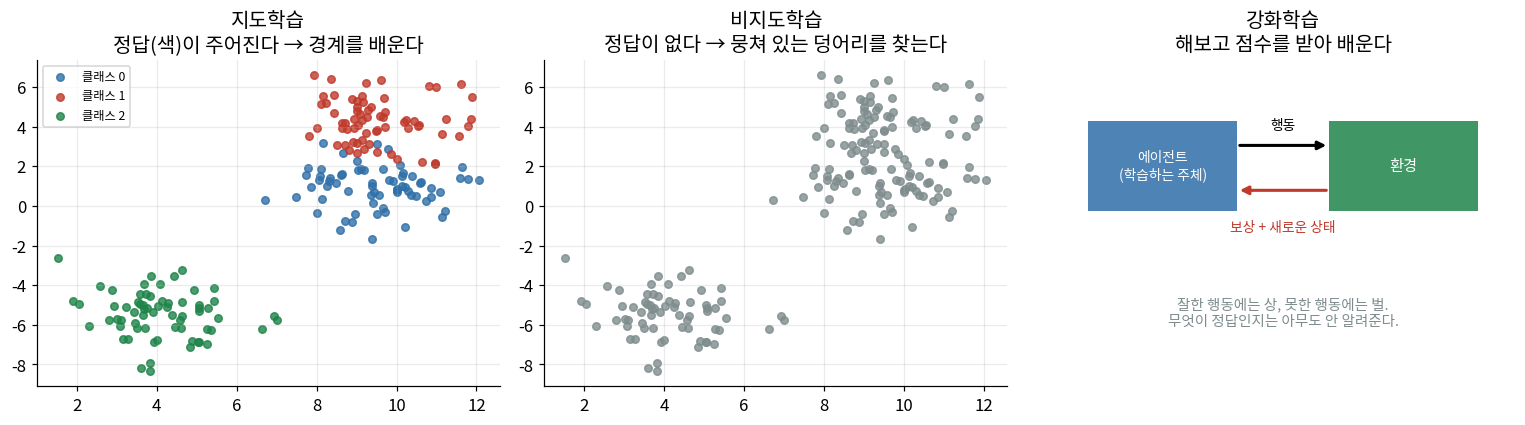

In [ ]:
from sklearn.datasets import make_blobs

Xb_, yb_ = make_blobs(n_samples=200, centers=3, cluster_std=1.1, random_state=4)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (1) 지도학습 — 색(정답)이 이미 칠해져 있다
for k, col in zip(range(3), [C["blue"], C["red"], C["green"]]):
    axes[0].scatter(Xb_[yb_ == k, 0], Xb_[yb_ == k, 1], s=24, color=col, alpha=.8,
                    label=f"클래스 {k}")
axes[0].set_title("지도학습\n정답(색)이 주어진다 → 경계를 배운다")
axes[0].legend(fontsize=8)

# (2) 비지도학습 — 색이 없다
axes[1].scatter(Xb_[:, 0], Xb_[:, 1], s=24, color=C["gray"], alpha=.8)
axes[1].set_title("비지도학습\n정답이 없다 → 뭉쳐 있는 덩어리를 찾는다")

# (3) 강화학습 — 개념도
axes[2].add_patch(plt.Rectangle((.08, .58), .32, .22, facecolor=C["blue"], alpha=.85))
axes[2].text(.24, .69, "에이전트\n(학습하는 주체)", ha="center", va="center", color="white", fontsize=9)
axes[2].add_patch(plt.Rectangle((.60, .58), .32, .22, facecolor=C["green"], alpha=.85))
axes[2].text(.76, .69, "환경", ha="center", va="center", color="white", fontsize=10)
axes[2].annotate("", xy=(.60, .74), xytext=(.40, .74),
                 arrowprops=dict(arrowstyle="-|>", lw=2, color="black"))
axes[2].text(.50, .78, "행동", ha="center", fontsize=9)
axes[2].annotate("", xy=(.40, .63), xytext=(.60, .63),
                 arrowprops=dict(arrowstyle="-|>", lw=2, color=C["red"]))
axes[2].text(.50, .53, "보상 + 새로운 상태", ha="center", fontsize=9, color=C["red"])
axes[2].text(.5, .30, "잘한 행동에는 상, 못한 행동에는 벌.\n무엇이 정답인지는 아무도 안 알려준다.",
             ha="center", fontsize=9.5, color=C["gray"])
axes[2].set_xlim(0, 1); axes[2].set_ylim(.15, .95); axes[2].axis("off"); axes[2].grid(False)
axes[2].set_title("강화학습\n해보고 점수를 받아 배운다")

fig.tight_layout()
save(fig, "A03_three_learning_types")
plt.show()

### 2-1. 비지도학습 맛보기 — 정답 없이 무리를 찾기

붓꽃(iris) 데이터로 확인해 봅시다. 꽃받침과 꽃잎의 길이·너비 4개 값이 있고, 실제로는 세 품종이 섞여 있습니다.
**품종 정보를 숨기고** 컴퓨터에게 "알아서 세 무리로 나눠봐"라고 시켜 보겠습니다.

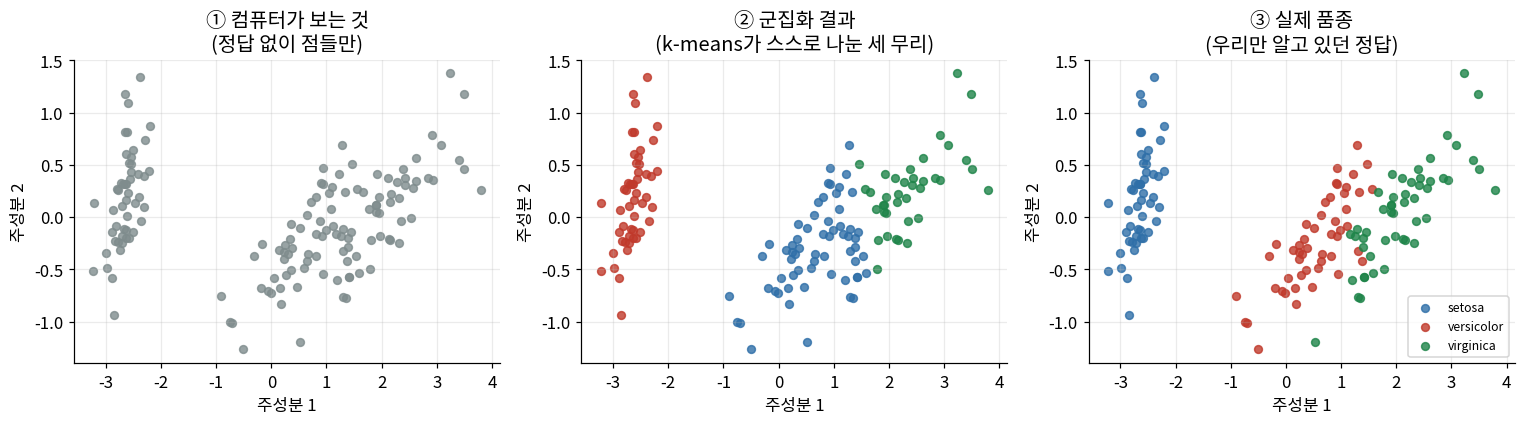

정답을 한 번도 보지 않았는데 실제 품종과 89.3% 일치했습니다.
왼쪽 무리는 거의 완벽하게 분리됐고, 오른쪽 두 무리는 경계 부근에서 섞였습니다.


In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

iris = load_iris()
Xi, yi = iris.data, iris.target

Xi2 = PCA(n_components=2).fit_transform(Xi)          # 4차원 → 2차원으로 눌러서 그림으로 볼 수 있게
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xi)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(Xi2[:, 0], Xi2[:, 1], s=26, color=C["gray"], alpha=.8)
axes[0].set_title("① 컴퓨터가 보는 것\n(정답 없이 점들만)")

for k, col in zip(range(3), [C["blue"], C["red"], C["green"]]):
    axes[1].scatter(Xi2[km.labels_ == k, 0], Xi2[km.labels_ == k, 1], s=26, color=col, alpha=.8)
axes[1].set_title("② 군집화 결과\n(k-means가 스스로 나눈 세 무리)")

for k, col, name in zip(range(3), [C["blue"], C["red"], C["green"]], iris.target_names):
    axes[2].scatter(Xi2[yi == k, 0], Xi2[yi == k, 1], s=26, color=col, alpha=.8, label=name)
axes[2].set_title("③ 실제 품종\n(우리만 알고 있던 정답)")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("주성분 1"); ax.set_ylabel("주성분 2")
fig.tight_layout()
save(fig, "A04_unsupervised_kmeans")
plt.show()

from itertools import permutations

# 군집 번호와 품종 번호는 서로 다르게 붙으므로, 가장 잘 맞는 대응을 찾아 일치율을 계산
best = max(np.mean([perm[c] for c in km.labels_] == yi) for perm in permutations(range(3)))
print(f"정답을 한 번도 보지 않았는데 실제 품종과 {best:.1%} 일치했습니다.")
print("왼쪽 무리는 거의 완벽하게 분리됐고, 오른쪽 두 무리는 경계 부근에서 섞였습니다.")

여기서 두 가지를 짚고 갑니다.

**첫째, 군집의 번호에는 의미가 없습니다.** 컴퓨터가 붙인 0번 무리가 setosa인지 versicolor인지는 알 수 없습니다.
"이 셋은 서로 다르다"까지만 말해 줄 뿐, 그게 무엇인지는 사람이 해석해야 합니다.

**둘째, 정답이 없으니 성능을 재기 어렵습니다.**
방금은 우리가 정답을 알고 있어서 비교했지만, 실제 비지도학습 상황에서는 비교할 정답이 없습니다.
"고객을 5개 그룹으로 나눴는데 이게 잘 나눈 건가?"라는 질문에는 깔끔한 답이 없습니다.
그래서 오늘 배울 손실·위험도 같은 개념이 지도학습에서 훨씬 선명하게 정의됩니다.

또 하나, 위 그림에서 4차원 데이터를 2차원으로 눌러서 그렸습니다.
이것도 비지도학습(**차원 축소**, PCA)입니다. 정답 없이 데이터의 구조만 보고 축을 새로 잡은 겁니다.

### 2-2. 강화학습 맛보기 — 해보고 배우기

슬롯머신 10대가 있습니다. 각 기계의 평균 당첨금은 다르지만 우리는 모릅니다.
1,000번 당길 기회가 있을 때, 어떻게 해야 총 상금이 커질까요?

여기에 강화학습의 핵심 딜레마가 들어 있습니다.
**지금까지 제일 좋았던 기계만 계속 당길 것인가(활용), 아니면 가끔 다른 기계도 시도해 볼 것인가(탐험).**

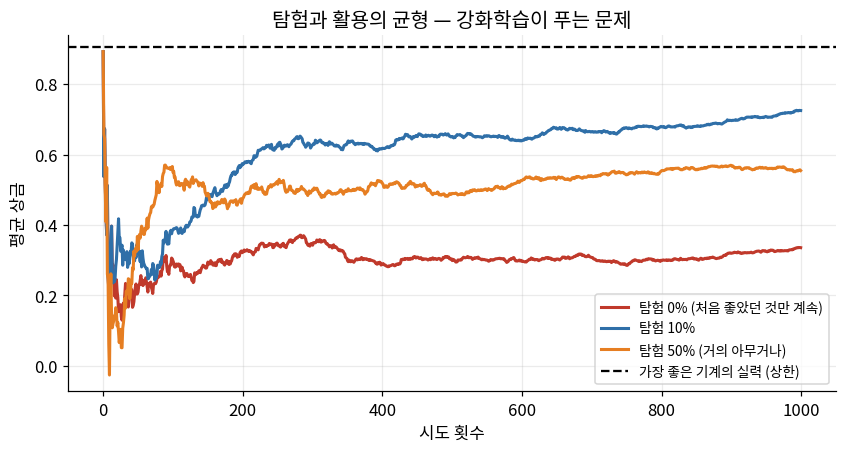

In [ ]:
def bandit_run(eps, steps=1000, arms=10, seed=1):
    r = np.random.default_rng(seed)
    true_mean = r.normal(0, 1, arms)          # 각 기계의 진짜 실력 (우리는 모름)
    q = np.zeros(arms)                        # 지금까지 추정한 실력
    cnt = np.zeros(arms)
    rewards = []
    for t in range(steps):
        if r.random() < eps:
            a = r.integers(arms)              # 탐험: 아무거나 당겨본다
        else:
            a = int(np.argmax(q))             # 활용: 제일 좋아 보이는 것을 당긴다
        reward = r.normal(true_mean[a], 1)
        cnt[a] += 1
        q[a] += (reward - q[a]) / cnt[a]      # 평균을 갱신
        rewards.append(reward)
    return np.array(rewards), true_mean.max()


fig, ax = plt.subplots(figsize=(9, 4.2))
for eps, col, name in [(0.0, C["red"], "탐험 0% (처음 좋았던 것만 계속)"),
                       (0.1, C["blue"], "탐험 10%"),
                       (0.5, C["orange"], "탐험 50% (거의 아무거나)")]:
    rw, best = bandit_run(eps)
    ax.plot(np.cumsum(rw) / np.arange(1, len(rw) + 1), color=col, lw=2, label=name)
ax.axhline(best, color="black", ls="--", lw=1.5, label="가장 좋은 기계의 실력 (상한)")
ax.set_xlabel("시도 횟수"); ax.set_ylabel("평균 상금")
ax.legend(fontsize=9)
ax.set_title("탐험과 활용의 균형 — 강화학습이 푸는 문제")
save(fig, "A05_bandit")
plt.show()

탐험을 전혀 안 하면 초반에 우연히 좋았던 기계에 갇힙니다. 너무 많이 하면 아는 걸 써먹지 못합니다.
적당히 섞은 쪽이 이깁니다. 이 균형 문제가 강화학습의 출발점이고, 알파고와 로봇 제어가 여기서 확장된 것입니다.

> 참고로 요즘 자주 들리는 **자기지도학습(self-supervised)** 은 "정답을 데이터 안에서 스스로 만들어내는" 방식입니다.
> 문장의 다음 단어를 맞히게 시키면 정답 라벨을 사람이 붙이지 않아도 되죠. 대형 언어모델이 이 방식으로 학습합니다.

## 3. 데이터를 부르는 말과 프로젝트의 흐름

용어가 정리되어 있지 않으면 다음 장부터 계속 헷갈립니다. 표 하나로 끝냅시다.

In [ ]:
sample_table = pd.DataFrame({
    "면적(㎡)": [84, 59, 114, 84, 134],
    "연식(년)": [5, 12, 3, 20, 8],
    "역까지(m)": [350, 800, 200, 1200, 450],
    "가격(억원)": [9.2, 5.1, 14.0, 6.3, 15.5],
})
display(sample_table)

print("행(row) 하나  = 샘플(sample), 관측치, 데이터 포인트 — 여기서는 아파트 한 채")
print("앞의 세 열     = 특징(feature), 설명변수, 입력 X — 우리가 알고 있는 정보")
print("마지막 열      = 타깃(target), 반응변수, 출력 Y — 우리가 맞히고 싶은 것")
print(f"이 데이터는 샘플 {len(sample_table)}개, 특징 {sample_table.shape[1]-1}개짜리입니다.")

,면적(㎡),연식(년),역까지(m),가격(억원)
0,84,5,350,9.2
1,59,12,800,5.1
2,114,3,200,14.0
3,84,20,1200,6.3
4,134,8,450,15.5


행(row) 하나  = 샘플(sample), 관측치, 데이터 포인트 — 여기서는 아파트 한 채
앞의 세 열     = 특징(feature), 설명변수, 입력 X — 우리가 알고 있는 정보
마지막 열      = 타깃(target), 반응변수, 출력 Y — 우리가 맞히고 싶은 것
이 데이터는 샘플 5개, 특징 3개짜리입니다.


같은 것을 부르는 말이 분야마다 다릅니다. 처음에는 혼란스럽지만 곧 익숙해집니다.

| 이 수업에서 | 통계학에서 | 머신러닝 현업에서 |
|---|---|---|
| 입력 $X$ | 설명변수, 독립변수 | 특징(feature), 피처 |
| 출력 $Y$ | 반응변수, 종속변수 | 타깃(target), 레이블(label) |
| 관측치 | 개체, 표본 단위 | 샘플, 데이터 포인트, 행 |
| 예측함수 $f$ | 회귀함수 | 모델(model) |

### 데이터를 나누는 이유

머신러닝에서 절대 어기면 안 되는 규칙이 하나 있습니다.
**공부한 문제로 시험을 보면 안 됩니다.**

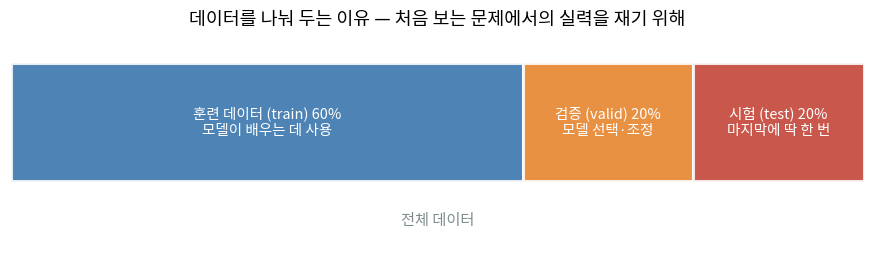

In [ ]:
fig, ax = plt.subplots(figsize=(10, 2.6))
parts = [(0.00, 0.60, "훈련 데이터 (train) 60%\n모델이 배우는 데 사용", C["blue"]),
         (0.60, 0.20, "검증 (valid) 20%\n모델 선택·조정", C["orange"]),
         (0.80, 0.20, "시험 (test) 20%\n마지막에 딱 한 번", C["red"])]
for x0, w, label, col in parts:
    ax.add_patch(plt.Rectangle((x0, .3), w, .4, facecolor=col, alpha=.85, edgecolor="white", lw=2))
    ax.text(x0 + w / 2, .5, label, ha="center", va="center", color="white", fontsize=9.5)
ax.text(0.5, 0.15, "전체 데이터", ha="center", fontsize=10, color=C["gray"])
ax.set_xlim(0, 1); ax.set_ylim(.05, .8); ax.axis("off"); ax.grid(False)
ax.set_title("데이터를 나눠 두는 이유 — 처음 보는 문제에서의 실력을 재기 위해", fontsize=12)
save(fig, "A06_data_split")
plt.show()

모의고사를 100번 풀어서 답을 외운 학생이 그 모의고사에서 만점을 받았다고 수능도 잘 볼까요?
모델도 똑같습니다. 배운 데이터에서의 점수는 실력이 아니라 **외운 정도**일 수 있습니다.
그래서 데이터를 처음부터 갈라 두고, 시험용은 마지막까지 열어보지 않습니다.
이 이야기는 뒤에서 숫자로 다시 확인합니다.

### 머신러닝 프로젝트의 실제 흐름

수업에서는 모델 만드는 부분만 크게 다루지만, 실무에서 모델링이 차지하는 비중은 생각보다 작습니다.

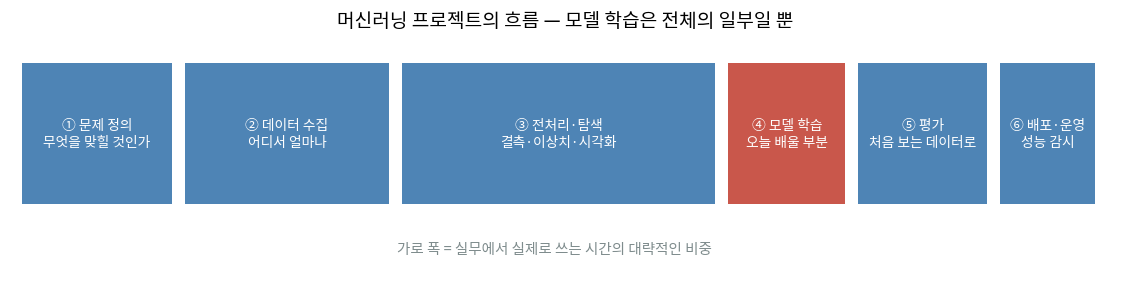

In [ ]:
steps = ["① 문제 정의\n무엇을 맞힐 것인가", "② 데이터 수집\n어디서 얼마나", "③ 전처리·탐색\n결측·이상치·시각화",
         "④ 모델 학습\n오늘 배울 부분", "⑤ 평가\n처음 보는 데이터로", "⑥ 배포·운영\n성능 감시"]
weights = [.15, .20, .30, .12, .13, .10]

fig, ax = plt.subplots(figsize=(13, 2.9))
x = 0.01
for s, w, in zip(steps, weights):
    col = C["red"] if "④" in s else C["blue"]
    ax.add_patch(plt.Rectangle((x, .32), w - .012, .40, facecolor=col, alpha=.85))
    ax.text(x + (w - .012) / 2, .52, s, ha="center", va="center", color="white", fontsize=9)
    x += w
ax.text(0.5, 0.18, "가로 폭 = 실무에서 실제로 쓰는 시간의 대략적인 비중", ha="center",
        fontsize=9.5, color=C["gray"])
ax.set_xlim(0, 1.02); ax.set_ylim(.1, .8); ax.axis("off"); ax.grid(False)
ax.set_title("머신러닝 프로젝트의 흐름 — 모델 학습은 전체의 일부일 뿐", fontsize=12.5)
save(fig, "A07_project_flow")
plt.show()

데이터를 모으고 정리하는 데 시간의 절반 이상이 갑니다.
"어떤 모델을 쓸까"보다 "무엇을 맞힐 것인가"와 "데이터가 믿을 만한가"가 훨씬 중요합니다.

### 머신러닝을 쓰면 안 되는 경우

마지막으로, 오히려 이게 더 실용적인 지식입니다. 아래에 해당하면 머신러닝을 꺼내지 마세요.

1. **규칙이 이미 명확할 때.** 부가세 계산에 모델을 학습시킬 이유가 없습니다.
2. **데이터가 없을 때.** 예시가 없으면 배울 수가 없습니다. 수십 건으로는 아무것도 못 합니다.
3. **왜 그런 결정을 했는지 반드시 설명해야 할 때.** 대출 거절 사유를 "모델이 그렇게 판단했습니다"로 답할 수는 없습니다.
4. **틀리면 되돌릴 수 없는 결정일 때.** 모델은 항상 일정 비율로 틀립니다. 오늘 5장에서 왜 그런지 배웁니다.
5. **앞으로의 환경이 과거와 완전히 다를 때.** 과거에서 배운 규칙이 미래에 통한다는 보장이 사라집니다.

> **여기까지가 도입입니다.** 지금부터는 지도학습 하나만 붙잡고, 그것을 수학으로 정확히 적는 연습을 합니다.
> 앞에서 말로 한 이야기를 기호로 바꾸는 작업이라고 생각하면 됩니다.

---
# 제2부 — 예측 문제를 수학으로 적기

## 4. 지도학습을 기호로 적기

1장에서 말로 설명한 것을 이제 기호로 바꿉니다. 앞으로 나올 모든 식이 이 네 기호로 이루어져 있으니
여기서 한 번만 확실히 정리하고 갑시다.

- 입력 $X \in \mathcal{X}$ : 우리가 관측할 수 있는 것 (메일 본문, 집의 면적, 환자의 검사 수치)
- 출력 $Y \in \mathcal{Y}$ : 우리가 맞히고 싶은 것 (스팸 여부, 집값, 질병 유무)
- 예측함수 $f : \mathcal{X} \to \mathcal{Y}$ : 입력을 받아 출력을 내놓는 규칙
- 데이터 $D_n = \{(X_i, Y_i)\}_{i=1}^{n}$ : $P_{XY}$ 에서 독립적으로 뽑힌 $n$ 개의 예시

여기서 가장 중요한 가정이 하나 숨어 있습니다.
**우리가 가진 데이터와 앞으로 만날 데이터가 같은 분포 $P_{XY}$ 에서 나온다**는 가정입니다.
이 가정이 깨지면(예: 서울 데이터로 학습해서 뉴욕 집값을 예측) 아무리 좋은 모델도 소용이 없습니다.

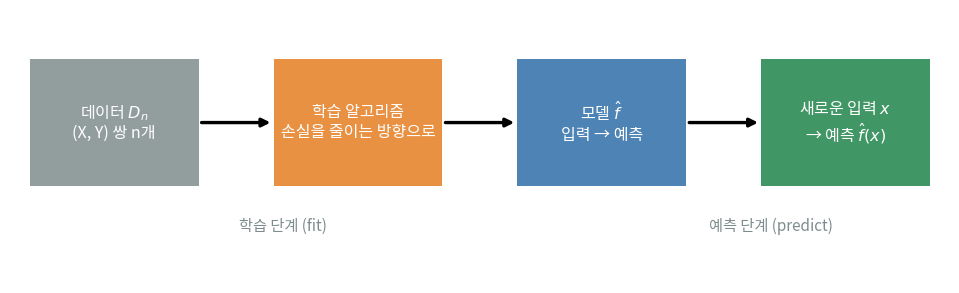

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [
    (0.02, "데이터 $D_n$\n(X, Y) 쌍 n개", C["gray"]),
    (0.28, "학습 알고리즘\n손실을 줄이는 방향으로", C["orange"]),
    (0.54, "모델 $\\hat{f}$\n입력 → 예측", C["blue"]),
    (0.80, "새로운 입력 $x$\n→ 예측 $\\hat{f}(x)$", C["green"]),
]
for x0, text, col in boxes:
    ax.add_patch(plt.Rectangle((x0, .30), .18, .40, facecolor=col, alpha=.85))
    ax.text(x0 + .09, .50, text, ha="center", va="center", color="white", fontsize=10.5)
for x0 in [0.20, 0.46, 0.72]:
    ax.annotate("", xy=(x0 + .08, .5), xytext=(x0, .5),
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color="black"))
ax.text(0.29, 0.16, "학습 단계 (fit)", ha="center", fontsize=10, color=C["gray"])
ax.text(0.81, 0.16, "예측 단계 (predict)", ha="center", fontsize=10, color=C["gray"])
ax.set_xlim(0, 1); ax.set_ylim(0, .85); ax.axis("off"); ax.grid(False)
save(fig, "M01_pipeline")
plt.show()

### 회귀와 분류

지도학습은 출력 $Y$ 의 생김새에 따라 두 갈래로 나뉩니다.

| | 회귀 (Regression) | 분류 (Classification) |
|---|---|---|
| 출력 $\mathcal{Y}$ | 실수 (연속적인 숫자) | 유한한 라벨 집합 |
| 예시 | 집값, 기온, 수요량, 체류시간 | 스팸 여부, 질병 유무, 숫자 인식 |
| 대표 손실 | 제곱오차 $(y - f(x))^2$ | 오분류 $\mathbf{1}(y \neq f(x))$ |
| 위험도의 이름 | 평균제곱오차 MSE | 오분류 확률 |

말로만 보면 헷갈리니 같은 상황을 두 문제로 만들어 보겠습니다.
아파트 데이터에서 "가격이 얼마일까"를 물으면 회귀, "이 매물이 한 달 안에 팔릴까"를 물으면 분류입니다.

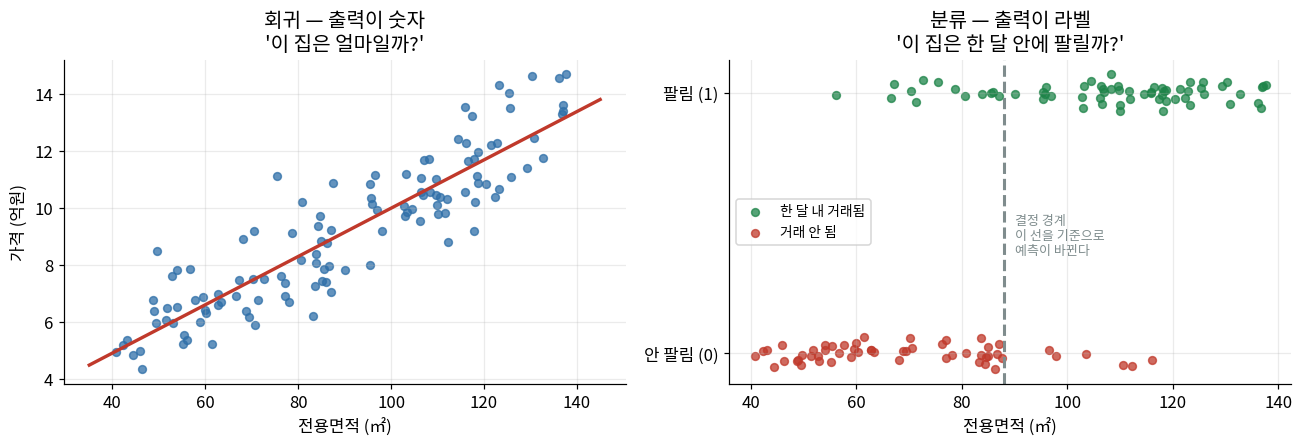

In [ ]:
n = 120
area = rng.uniform(40, 140, n)                                  # 전용면적 (㎡)
price = 1.5 + 0.085 * area + rng.normal(0, 1.1, n)              # 가격 (억원)
sold = (0.11 * area - rng.normal(9.5, 2.2, n) > 0).astype(int)  # 한 달 내 거래 성사 여부

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(area, price, s=26, color=C["blue"], alpha=.75)
b1, b0 = np.polyfit(area, price, 1)
xs = np.linspace(35, 145, 50)
axes[0].plot(xs, b0 + b1 * xs, color=C["red"], lw=2.2)
axes[0].set_xlabel("전용면적 (㎡)"); axes[0].set_ylabel("가격 (억원)")
axes[0].set_title("회귀 — 출력이 숫자\n'이 집은 얼마일까?'")

axes[1].scatter(area[sold == 1], sold[sold == 1] + rng.normal(0, .03, (sold == 1).sum()),
                s=26, color=C["green"], alpha=.75, label="한 달 내 거래됨")
axes[1].scatter(area[sold == 0], sold[sold == 0] + rng.normal(0, .03, (sold == 0).sum()),
                s=26, color=C["red"], alpha=.75, label="거래 안 됨")
axes[1].axvline(88, color=C["gray"], ls="--", lw=2)
axes[1].text(90, .38, "결정 경계\n이 선을 기준으로\n예측이 바뀐다", fontsize=8.5, color=C["gray"])
axes[1].set_yticks([0, 1], ["안 팔림 (0)", "팔림 (1)"])
axes[1].set_xlabel("전용면적 (㎡)")
axes[1].set_title("분류 — 출력이 라벨\n'이 집은 한 달 안에 팔릴까?'")
axes[1].legend(fontsize=9, loc="center left")
fig.tight_layout()
save(fig, "M02_regression_vs_classification")
plt.show()

> **생각해 볼 것**: 아래 문제들은 회귀입니까 분류입니까?
>
> (1) 내일 서울 최고기온 (2) 이 리뷰가 별 몇 개인지 (3) 이 사진이 개인지 고양이인지
> (4) 이 고객이 다음 달에 이탈할 확률 (5) 배달 도착까지 걸리는 시간
>
> 헷갈리는 건 (2)와 (4)입니다. (2)는 별점을 순서형 라벨로 보면 분류, 숫자로 보면 회귀입니다.
> (4)는 출력이 확률(0~1 사이 숫자)이라 회귀처럼 보이지만, 최종 목적이 이탈/잔존 판정이면 분류로 다룹니다.
> **문제를 어느 쪽으로 세울지는 데이터가 아니라 목적이 정합니다.**

## 5. 예측함수를 고른다는 것

이제 데이터 20개를 놓고 시작합시다. 우리가 할 일은 이 점들을 설명하는 함수 $f$ 를 하나 고르는 것입니다.

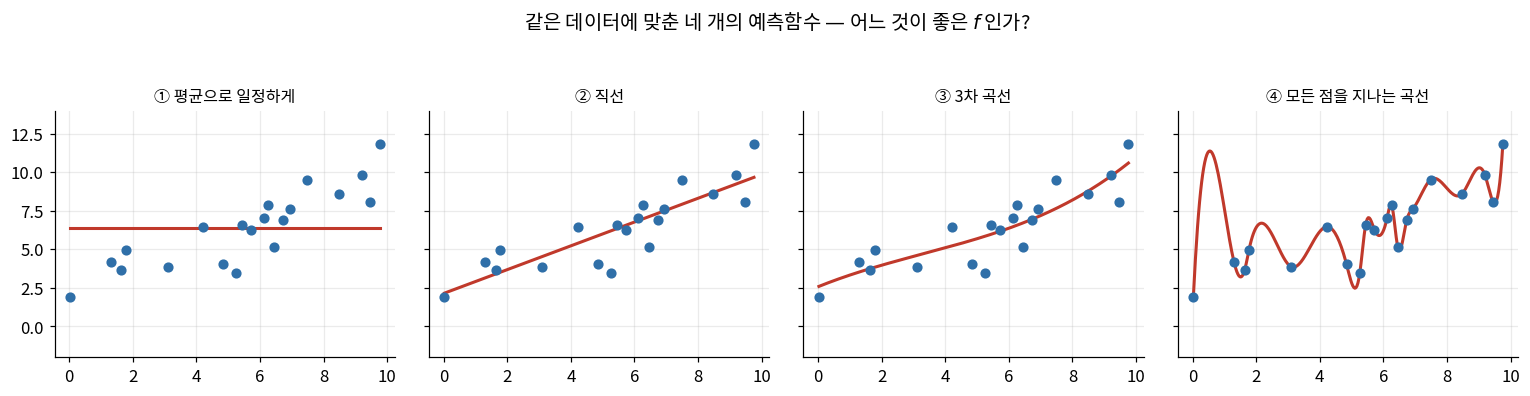

In [ ]:
from scipy.interpolate import CubicSpline

demo = np.random.default_rng(68)                     # 예제용 난수 (재현 가능)
n = 20
x = np.sort(demo.uniform(0, 10, n))
true_f = lambda t: 2 + 0.8 * t                       # 우리는 모르는 진짜 관계
y = true_f(x) + demo.normal(0, 1.2, n)

grid = np.linspace(x.min(), x.max(), 300)
candidates = {
    "① 평균으로 일정하게": np.full_like(grid, y.mean()),
    "② 직선": np.polyval(np.polyfit(x, y, 1), grid),
    "③ 3차 곡선": np.polyval(np.polyfit(x, y, 3), grid),
    "④ 모든 점을 지나는 곡선": CubicSpline(x, y)(grid),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharey=True)
for ax, (name, yy) in zip(axes, candidates.items()):
    ax.scatter(x, y, s=32, color=C["blue"], zorder=3)
    ax.plot(grid, yy, color=C["red"], lw=2)
    ax.set_title(name, fontsize=10.5)
    ax.set_ylim(-2, 14)
fig.suptitle("같은 데이터에 맞춘 네 개의 예측함수 — 어느 것이 좋은 $f$ 인가?", y=1.05, fontsize=13)
fig.tight_layout()
save(fig, "M03_candidate_functions")
plt.show()

④는 20개 점을 전부 정확히 지나갑니다. 훈련 데이터에서의 오차가 0입니다.
그런데 이 함수를 믿고 $x=7.5$ 에서 예측하고 싶습니까?

눈으로 "이게 좋아 보인다"고 말하는 것은 과학이 아닙니다.
**좋다/나쁘다를 숫자로 매기는 규칙**이 필요합니다. 그 규칙이 손실 함수입니다.

## 6. 손실 함수 Loss $\ell(y, f(x))$

손실 함수는 **관측치 하나**에 대해 "얼마나 틀렸는가"를 재는 함수입니다.

$$\ell : \mathcal{Y} \times \mathcal{Y} \to \mathbb{R}_{\ge 0}, \qquad \ell(y, \hat{y}) \ \text{가 작을수록 좋다}$$

회귀에서 가장 많이 쓰는 것이 제곱오차 $\ell(y, \hat y) = (y - \hat y)^2$ 입니다.
아래 그림에서 점과 직선을 잇는 세로 선분 하나하나가 그 점의 오차이고, 그것을 제곱한 값이 손실입니다.

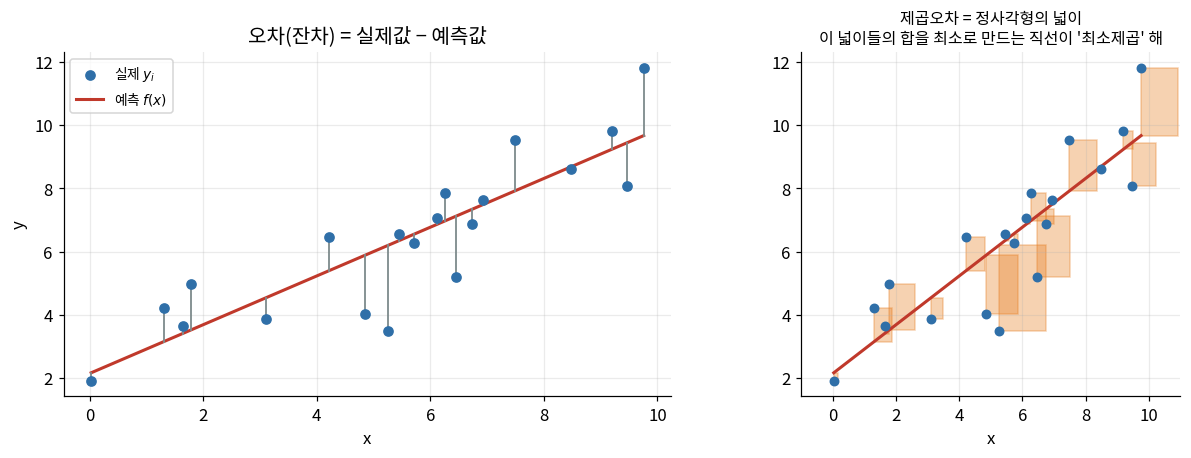

관측치별 손실 (앞 5개): [0.061 1.119 0.054 2.153 0.451]
평균 제곱오차 MSE      : 1.511


In [ ]:
b1, b0 = np.polyfit(x, y, 1)
pred = b0 + b1 * x
resid = y - pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

axes[0].scatter(x, y, s=36, color=C["blue"], zorder=3, label="실제 $y_i$")
axes[0].plot(grid, b0 + b1 * grid, color=C["red"], lw=2, label="예측 $f(x)$")
for xi, yi, pi in zip(x, y, pred):
    axes[0].plot([xi, xi], [yi, pi], color=C["gray"], lw=1.2, zorder=2)
axes[0].set_title("오차(잔차) = 실제값 − 예측값")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].legend(fontsize=9)

# 오차를 제곱하면 넓이가 된다 — '최소제곱'이라는 이름의 유래
axes[1].scatter(x, y, s=30, color=C["blue"], zorder=3)
axes[1].plot(grid, b0 + b1 * grid, color=C["red"], lw=2)
for xi, yi, pi in zip(x, y, pred):
    e = yi - pi
    axes[1].add_patch(plt.Rectangle((xi, min(yi, pi)), abs(e) * 0.55, abs(e),
                                    facecolor=C["orange"], alpha=.35, edgecolor=C["orange"]))
axes[1].set_title("제곱오차 = 정사각형의 넓이\n이 넓이들의 합을 최소로 만드는 직선이 '최소제곱' 해", fontsize=10.5)
axes[1].set_xlabel("x"); axes[1].set_aspect("equal"); axes[1].set_xlim(-1, 11)
fig.tight_layout()
save(fig, "M04_residuals")
plt.show()

print(f"관측치별 손실 (앞 5개): {np.round(resid[:5] ** 2, 3)}")
print(f"평균 제곱오차 MSE      : {np.mean(resid ** 2):.3f}")

### 손실 함수는 하나가 아니다

제곱오차가 유일한 답은 아닙니다. 자주 쓰는 회귀 손실 세 가지를 비교해 봅시다.

| 이름 | 식 | 성격 |
|---|---|---|
| 제곱손실 (L2) | $(y-\hat y)^2$ | 큰 오차에 아주 민감. 미분이 쉬워 계산에 유리 |
| 절대손실 (L1) | $\lvert y-\hat y \rvert$ | 이상치에 강함. 0에서 미분 불가 |
| 후버손실 (Huber) | 작으면 L2, 크면 L1 | 두 성질의 절충 |

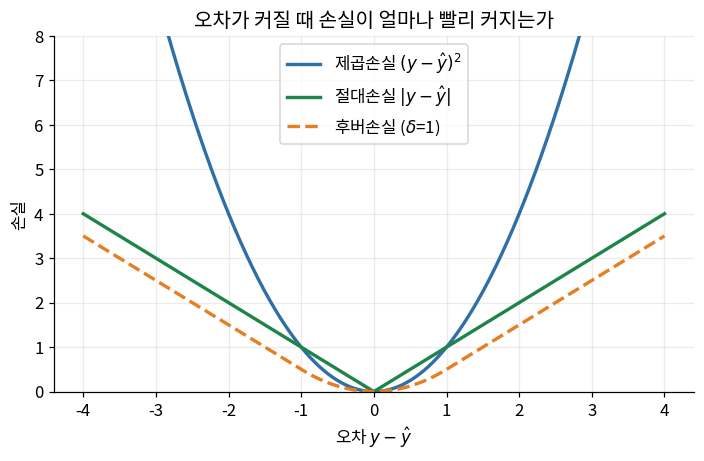

In [ ]:
e = np.linspace(-4, 4, 400)


def huber(e, d=1.0):
    return np.where(np.abs(e) <= d, 0.5 * e ** 2, d * (np.abs(e) - 0.5 * d))


fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(e, e ** 2, color=C["blue"], lw=2.2, label="제곱손실 $(y-\\hat{y})^2$")
ax.plot(e, np.abs(e), color=C["green"], lw=2.2, label="절대손실 $|y-\\hat{y}|$")
ax.plot(e, huber(e, 1.0), color=C["orange"], lw=2.2, ls="--", label="후버손실 ($\\delta$=1)")
ax.set_xlabel("오차 $y - \\hat{y}$"); ax.set_ylabel("손실")
ax.set_ylim(0, 8); ax.legend()
ax.set_title("오차가 커질 때 손실이 얼마나 빨리 커지는가")
save(fig, "M05_loss_functions")
plt.show()

차이가 실제로 어떤 결과를 만드는지 봅시다. 데이터에 이상치를 하나 넣고 두 손실로 각각 직선을 맞춰 보겠습니다.

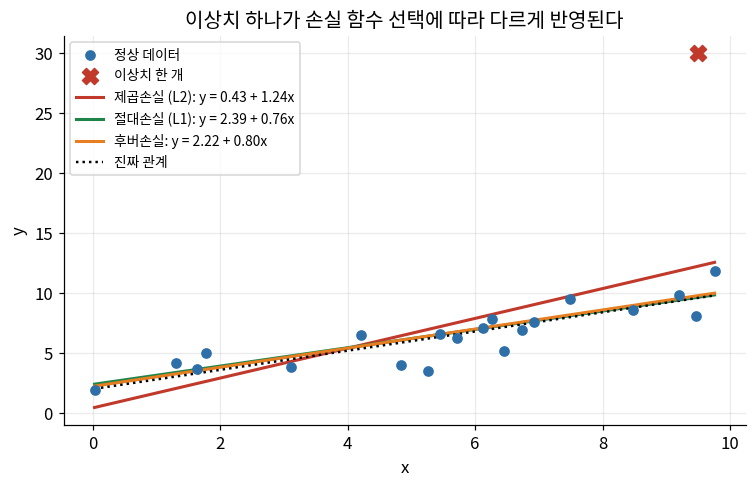

In [ ]:
from scipy.optimize import minimize

x_out = np.append(x, 9.5)
y_out = np.append(y, 30.0)          # 입력 오류로 들어간 이상치 한 개


def fit_loss(kind):
    def obj(p):
        r = y_out - (p[0] + p[1] * x_out)
        if kind == "l2":
            return np.mean(r ** 2)
        if kind == "l1":
            return np.mean(np.abs(r))
        return np.mean(huber(r, 1.0))
    return minimize(obj, [0.0, 0.0], method="Nelder-Mead",
                    options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 5000}).x


fits = {"제곱손실 (L2)": fit_loss("l2"), "절대손실 (L1)": fit_loss("l1"), "후버손실": fit_loss("huber")}

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=36, color=C["blue"], zorder=3, label="정상 데이터")
ax.scatter([9.5], [30.0], s=110, color=C["red"], marker="X", zorder=4, label="이상치 한 개")
for (name, p), col in zip(fits.items(), [C["red"], C["green"], C["orange"]]):
    ax.plot(grid, p[0] + p[1] * grid, lw=2, color=col,
            label=f"{name}: y = {p[0]:.2f} + {p[1]:.2f}x")
ax.plot(grid, true_f(grid), color="black", ls=":", lw=1.6, label="진짜 관계")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=9)
ax.set_title("이상치 하나가 손실 함수 선택에 따라 다르게 반영된다")
save(fig, "M06_loss_robustness")
plt.show()

제곱손실은 이상치 하나 때문에 직선 전체가 위로 들립니다. 오차를 제곱하니까 그 점의 손실이 압도적으로 커지기 때문입니다.
절대손실과 후버손실은 진짜 관계에 훨씬 가깝게 남아 있습니다.

0교시에서 본 **평균과 중위수의 관계와 똑같은 구조**입니다. 뒤에서 이유를 정확히 밝힙니다.

**여기서 기억할 것**: 손실 함수는 모델이 정하는 게 아니라 **우리가 문제에 맞게 고르는 것**입니다.
"큰 오차 한 번이 치명적인 문제"라면 제곱손실, "가끔 튀는 값이 섞이는 문제"라면 절대·후버손실이 맞습니다.

## 7. 위험도 Risk $R(f)$ — 손실과 무엇이 다른가

손실 $\ell(y, f(x))$ 은 **점 하나**에 대한 값입니다. 데이터가 바뀌면 값도 바뀝니다.
우리가 진짜 알고 싶은 것은 "이 모델이 앞으로 만날 모든 데이터에 대해 평균적으로 얼마나 틀리는가"입니다.
그것이 위험도입니다.

$$R(f) \;=\; \mathbb{E}_{(X,Y) \sim P_{XY}}\big[\ell(Y, f(X))\big]$$

| | 손실 Loss | 위험도 Risk |
|---|---|---|
| 대상 | 관측치 하나 | 분포 전체 |
| 값 | 데이터마다 다름 (확률변수) | 모델 $f$ 마다 하나로 정해진 수 |
| 계산 | 바로 계산 가능 | $P_{XY}$ 를 알아야 계산 가능 → **현실에서는 계산 불가** |

여기가 통계적 학습이론의 출발점입니다.
**우리가 최소화하고 싶은 것($R$)은 계산할 수 없고, 계산할 수 있는 것(데이터 위의 평균 손실)은 우리가 원하는 것이 아닙니다.**

이 노트북에서는 시뮬레이션이라는 특권을 씁니다. 진짜 분포 $P_{XY}$ 를 우리가 직접 만들면
$R(f)$ 를 (거의 정확히) 계산할 수 있고, 그러면 두 값을 비교해 볼 수 있습니다.

In [ ]:
# 진짜 세계를 정의한다 — 현실에서는 절대 알 수 없는 정보
SIGMA = 1.2


def true_g(x):
    """진짜 관계 g(x) = E[Y | X = x]"""
    return 2 + 0.8 * x


def sample_world(m, seed=None):
    """분포 P_XY 에서 m개를 뽑는다"""
    r = np.random.default_rng(seed) if seed is not None else rng
    xs = r.uniform(0, 10, m)
    ys = true_g(xs) + r.normal(0, SIGMA, m)
    return xs, ys


def true_risk(f, m=2_000_000):
    """R(f) = E[(Y - f(X))^2] 를 몬테카를로로 아주 정확히 계산"""
    xs, ys = sample_world(m, seed=0)
    return np.mean((ys - f(xs)) ** 2)


models = {
    "평균만 예측 f(x)=7": lambda t: np.full_like(np.asarray(t, float), 7.0),
    "기울기가 틀린 직선 f(x)=2+0.4x": lambda t: 2 + 0.4 * np.asarray(t, float),
    "진짜 관계 f(x)=2+0.8x": true_g,
}

for name, f in models.items():
    print(f"R(f) = {true_risk(f):6.3f}   ← {name}")

R(f) =  7.774   ← 평균만 예측 f(x)=7
R(f) =  6.769   ← 기울기가 틀린 직선 f(x)=2+0.4x
R(f) =  1.440   ← 진짜 관계 f(x)=2+0.8x


진짜 관계를 그대로 쓴 모델의 위험도가 1.44인데, 이것은 우연이 아닙니다.
$\sigma^2 = 1.2^2 = 1.44$, 즉 **잡음의 분산**입니다.

아무리 좋은 모델을 가져와도 위험도를 이 아래로 내릴 수 없습니다.
$Y$ 안에 $X$ 로 설명되지 않는 부분이 있기 때문입니다. 이것을 **줄일 수 없는 오차(irreducible error)** 라고 부릅니다.

### 경험적 위험은 진짜 위험에 수렴한다

현실에서 우리가 계산하는 것은 데이터 $n$ 개 위의 평균 손실, 즉 **경험적 위험**입니다.

$$\hat{R}_n(f) = \frac{1}{n}\sum_{i=1}^{n} \ell\big(Y_i, f(X_i)\big) \xrightarrow[\ n \to \infty\ ]{} R(f)$$

대수의 법칙 덕분에 $n$ 이 커지면 둘은 가까워집니다. 얼마나 빨리 가까워지는지 눈으로 봅시다.

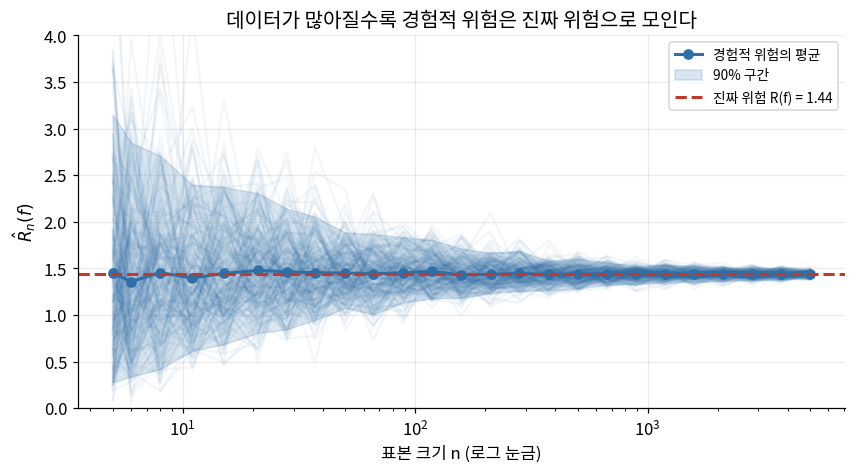

In [ ]:
f_true = true_g
R = true_risk(f_true)

ns = np.unique(np.logspace(0.7, 3.7, 25).astype(int))
reps = 200
emp = np.zeros((len(ns), reps))
for i, nn in enumerate(ns):
    for j in range(reps):
        xs, ys = sample_world(nn)
        emp[i, j] = np.mean((ys - f_true(xs)) ** 2)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(ns, emp, color=C["blue"], alpha=.06)
ax.plot(ns, emp.mean(axis=1), "o-", color=C["blue"], lw=2, label="경험적 위험의 평균")
ax.fill_between(ns, np.percentile(emp, 5, axis=1), np.percentile(emp, 95, axis=1),
                color=C["blue"], alpha=.18, label="90% 구간")
ax.axhline(R, color=C["red"], lw=2, ls="--", label=f"진짜 위험 R(f) = {R:.2f}")
ax.set_xscale("log")
ax.set_xlabel("표본 크기 n (로그 눈금)"); ax.set_ylabel("$\\hat{R}_n(f)$")
ax.set_ylim(0, 4); ax.legend(fontsize=9)
ax.set_title("데이터가 많아질수록 경험적 위험은 진짜 위험으로 모인다")
save(fig, "M07_empirical_risk_convergence")
plt.show()

n이 20일 때는 표본에 따라 0.6에서 2.5까지 흔들립니다. 이 상태에서 "모델 A가 B보다 낫다"고 결론 내리면 위험합니다.
0교시에서 본 "표본이 작으면 결과가 요동친다"가 그대로 반복됩니다.

### 훈련 데이터로 고르고 훈련 데이터로 평가하면 안 되는 이유

한 가지 더 중요한 사실이 있습니다.
**같은 데이터로 모델을 고르고 그 데이터로 성능을 재면, 성능이 실제보다 좋게 나옵니다.**

In [ ]:
n_train = 25
xs, ys = sample_world(n_train, seed=11)

rows = []
for deg in [1, 3, 6, 12]:
    coef = np.polyfit(xs, ys, deg)
    f_hat = lambda t, c=coef: np.polyval(c, t)
    rows.append({
        "다항식 차수": deg,
        "훈련 데이터에서의 오차": np.mean((ys - f_hat(xs)) ** 2),
        "진짜 위험 R(f̂)": true_risk(f_hat, m=200_000),
    })

pd.DataFrame(rows).round(3)

,다항식 차수,훈련 데이터에서의 오차,진짜 위험 R(f̂)
0,1,0.749,1.655
1,3,0.679,1.712
2,6,0.585,1.952
3,12,0.320,3.571


차수를 올리면 훈련 오차는 계속 내려가는데 진짜 위험은 오히려 폭발합니다.
훈련 오차는 모델의 성능이 아니라 **모델이 그 데이터를 얼마나 외웠는지**를 재고 있습니다.

그래서 실무에서는 데이터를 훈련용과 시험용으로 나눕니다. 12장에서 다시 다룹니다.

## 8. 최적 규칙 (Bayes Optimal Rule)

이론적으로 가장 좋은 예측함수는 무엇일까요? 정의는 간단합니다.

$$f^* = \arg\min_{f} \; \mathbb{E}\big[\ell(Y, f(X))\big], \qquad R(f^*) \le R(f) \ \ \text{for all } f$$

제곱손실을 쓰면 답이 아주 깔끔하게 나옵니다.

$$f^*(x) = \mathbb{E}[Y \mid X = x]$$

즉 **각 $x$ 에서 $Y$ 의 조건부 평균**이 최적입니다. 그리고 이때의 최소 위험도를 **베이즈 위험**이라고 부릅니다.

증명은 간단한 분해로 끝납니다. $g(x) = \mathbb{E}[Y|X=x]$ 라 두면

$$\mathbb{E}\big[(Y - f(X))^2\big]
= \underbrace{\mathbb{E}\big[(Y - g(X))^2\big]}_{\text{줄일 수 없는 오차} \sigma^2}
+ \underbrace{\mathbb{E}\big[(g(X) - f(X))^2\big]}_{\text{모델이 만든 오차} \ \ge 0}$$

앞항은 $f$ 와 무관하고 뒷항은 $f = g$ 일 때만 0이 됩니다. 수식으로 확인했으니 숫자로도 확인해 봅시다.

In [ ]:
def decompose(f, m=500_000):
    xs, ys = sample_world(m, seed=3)
    total = np.mean((ys - f(xs)) ** 2)
    irreducible = np.mean((ys - true_g(xs)) ** 2)
    model_part = np.mean((true_g(xs) - f(xs)) ** 2)
    return total, irreducible, model_part


rows = []
for name, f in {**models, "약간 어긋난 직선 f(x)=2.5+0.75x": lambda t: 2.5 + 0.75 * np.asarray(t, float)}.items():
    tot, irr, mod = decompose(f)
    rows.append({"모델": name, "R(f)": tot, "줄일 수 없는 오차": irr,
                 "모델이 만든 오차": mod, "두 항의 합": irr + mod})

pd.DataFrame(rows).round(3)

,모델,R(f),줄일 수 없는 오차,모델이 만든 오차,두 항의 합
0,평균만 예측 f(x)=7,7.756,1.441,6.318,7.759
1,기울기가 틀린 직선 f(x)=2+0.4x,6.789,1.441,5.346,6.787
2,진짜 관계 f(x)=2+0.8x,1.441,1.441,0.000,1.441
3,약간 어긋난 직선 f(x)=2.5+0.75x,1.523,1.441,0.083,1.524


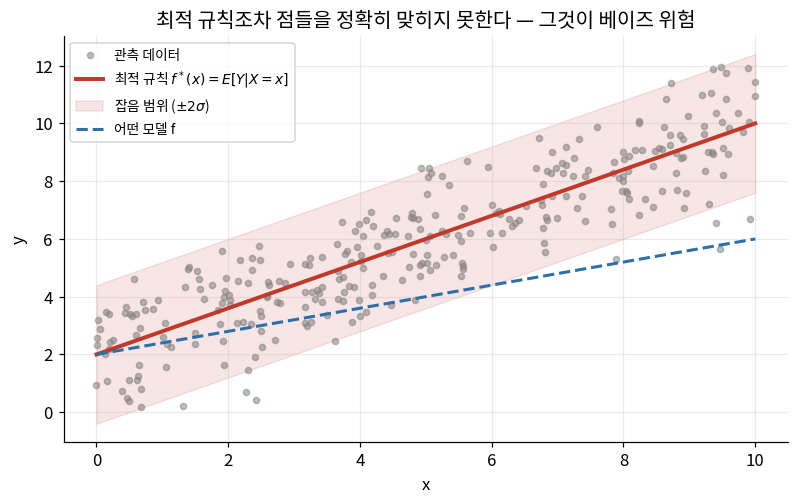

베이즈 위험 R(f*) = σ² = 1.440


In [ ]:
xs_p, ys_p = sample_world(300, seed=5)
gx = np.linspace(0, 10, 200)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.scatter(xs_p, ys_p, s=16, color=C["gray"], alpha=.55, label="관측 데이터")
ax.plot(gx, true_g(gx), color=C["red"], lw=2.6, label="최적 규칙 $f^*(x)=E[Y|X=x]$")
ax.fill_between(gx, true_g(gx) - 2 * SIGMA, true_g(gx) + 2 * SIGMA,
                color=C["red"], alpha=.12, label="잡음 범위 ($\\pm 2\\sigma$)")
ax.plot(gx, 2 + 0.4 * gx, color=C["blue"], lw=2, ls="--", label="어떤 모델 f")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=9)
ax.set_title("최적 규칙조차 점들을 정확히 맞히지 못한다 — 그것이 베이즈 위험")
save(fig, "M08_bayes_optimal")
plt.show()

print(f"베이즈 위험 R(f*) = σ² = {SIGMA**2:.3f}")

빨간 선이 이론상 도달 가능한 최선입니다. 그런데도 점들은 선 위에 있지 않습니다.
**모델을 아무리 개선해도 넘을 수 없는 벽이 있다**는 사실을 첫 시간에 받아들이는 것이 중요합니다.
"정확도 100%를 목표로 합시다" 같은 목표 설정이 왜 위험한지가 여기서 나옵니다.

### 손실을 바꾸면 최적 규칙도 바뀐다

6장에서 남겨둔 질문의 답입니다. 최적 규칙은 손실 함수에 따라 달라집니다.

| 손실 | 최적 규칙 $f^*(x)$ |
|---|---|
| 제곱손실 $(y-\hat y)^2$ | 조건부 **평균** $\mathbb{E}[Y \mid X=x]$ |
| 절대손실 $\lvert y-\hat y \rvert$ | 조건부 **중위수** $\text{median}(Y \mid X=x)$ |
| 분위손실 (quantile loss) | 조건부 **분위수** |

한쪽 꼬리가 긴 분포를 만들어 직접 확인해 봅시다. 예측값을 상수 $c$ 로 두고, $c$ 를 움직이며 두 위험도를 계산합니다.

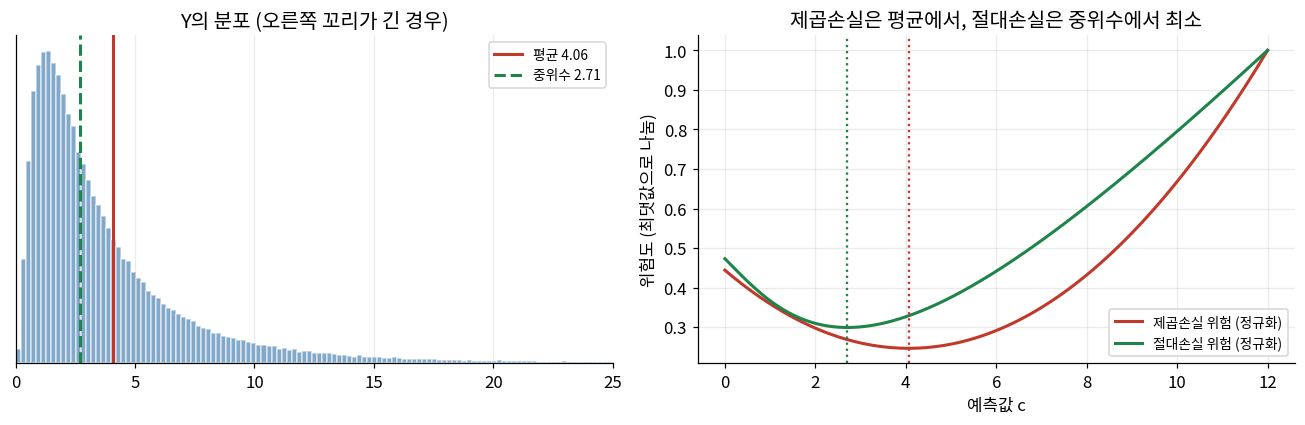

제곱손실을 최소로 만드는 c : 4.06  (평균 4.06)
절대손실을 최소로 만드는 c : 2.71  (중위수 2.71)


In [ ]:
skewed = rng.lognormal(mean=1.0, sigma=0.9, size=200_000)     # 오른쪽 꼬리가 긴 분포
cs = np.linspace(0, 12, 400)
risk_l2 = [(np.mean((skewed - c) ** 2)) for c in cs]
risk_l1 = [(np.mean(np.abs(skewed - c))) for c in cs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(skewed, bins=np.linspace(0, 25, 120), color=C["blue"], alpha=.6, edgecolor="white")
axes[0].axvline(skewed.mean(), color=C["red"], lw=2, label=f"평균 {skewed.mean():.2f}")
axes[0].axvline(np.median(skewed), color=C["green"], lw=2, ls="--", label=f"중위수 {np.median(skewed):.2f}")
axes[0].set_xlim(0, 25); axes[0].set_yticks([]); axes[0].legend(fontsize=9)
axes[0].set_title("Y의 분포 (오른쪽 꼬리가 긴 경우)")

axes[1].plot(cs, risk_l2 / np.max(risk_l2), color=C["red"], lw=2, label="제곱손실 위험 (정규화)")
axes[1].plot(cs, risk_l1 / np.max(risk_l1), color=C["green"], lw=2, label="절대손실 위험 (정규화)")
axes[1].axvline(skewed.mean(), color=C["red"], ls=":", lw=1.5)
axes[1].axvline(np.median(skewed), color=C["green"], ls=":", lw=1.5)
axes[1].set_xlabel("예측값 c"); axes[1].set_ylabel("위험도 (최댓값으로 나눔)")
axes[1].legend(fontsize=9)
axes[1].set_title("제곱손실은 평균에서, 절대손실은 중위수에서 최소")
fig.tight_layout()
save(fig, "M09_loss_determines_optimum")
plt.show()

print(f"제곱손실을 최소로 만드는 c : {cs[int(np.argmin(risk_l2))]:.2f}  (평균 {skewed.mean():.2f})")
print(f"절대손실을 최소로 만드는 c : {cs[int(np.argmin(risk_l1))]:.2f}  (중위수 {np.median(skewed):.2f})")

0교시에서 "평균이냐 중위수냐"를 고민했던 것이, 머신러닝에서는 **"어떤 손실 함수를 쓸 것인가"** 라는 문제로 그대로 옮겨옵니다.
배달 예상시간을 예측하는 서비스가 제곱손실을 쓰면 평균을, 절대손실을 쓰면 중위수를 맞히게 됩니다.
어느 쪽이 맞는지는 서비스가 결정할 문제입니다.

### 분류에서의 최적 규칙

분류에서 0-1 손실을 쓰면 최적 규칙은 **사후확률이 가장 큰 클래스**입니다.

$$f^*(x) = \arg\max_{k} \; P(Y = k \mid X = x)$$

두 클래스면 $P(Y=1|X=x) > 0.5$ 일 때 1로 예측하는 규칙입니다. 이때의 오분류 확률이 베이즈 오차입니다.

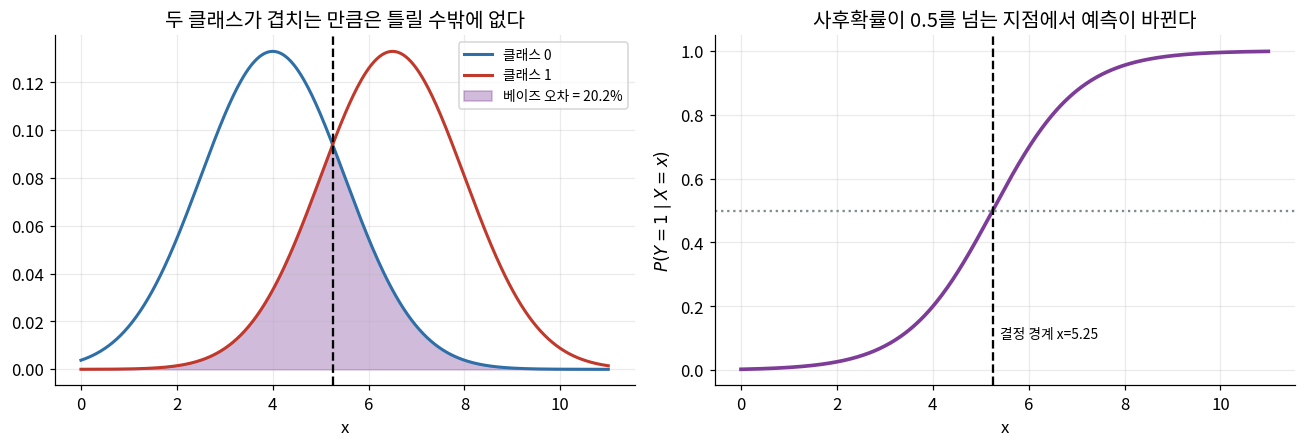

In [ ]:
from scipy import stats

mu0, mu1, sd = 4.0, 6.5, 1.5
prior = 0.5
gx = np.linspace(0, 11, 400)
d0, d1 = stats.norm(mu0, sd), stats.norm(mu1, sd)
post1 = prior * d1.pdf(gx) / (prior * d1.pdf(gx) + (1 - prior) * d0.pdf(gx))
boundary = (mu0 + mu1) / 2

bayes_err = prior * d1.cdf(boundary) + (1 - prior) * (1 - d0.cdf(boundary))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(gx, d0.pdf(gx) * (1 - prior), color=C["blue"], lw=2, label="클래스 0")
axes[0].plot(gx, d1.pdf(gx) * prior, color=C["red"], lw=2, label="클래스 1")
axes[0].fill_between(gx, np.minimum(d0.pdf(gx) * (1 - prior), d1.pdf(gx) * prior),
                     color=C["purple"], alpha=.35, label=f"베이즈 오차 = {bayes_err:.1%}")
axes[0].axvline(boundary, color="black", ls="--", lw=1.5)
axes[0].set_title("두 클래스가 겹치는 만큼은 틀릴 수밖에 없다")
axes[0].set_xlabel("x"); axes[0].legend(fontsize=9)

axes[1].plot(gx, post1, color=C["purple"], lw=2.4)
axes[1].axhline(.5, color=C["gray"], ls=":")
axes[1].axvline(boundary, color="black", ls="--", lw=1.5)
axes[1].text(boundary + .15, .1, f"결정 경계 x={boundary:.2f}", fontsize=9)
axes[1].set_xlabel("x"); axes[1].set_ylabel("$P(Y=1 \\mid X=x)$")
axes[1].set_title("사후확률이 0.5를 넘는 지점에서 예측이 바뀐다")
fig.tight_layout()
save(fig, "M10_bayes_classifier")
plt.show()

분류에서도 마찬가지로 **베이즈 오차 아래로는 내려갈 수 없습니다.**
정확도 92%가 나왔을 때 그것이 잘한 것인지 아닌지는, 이 문제의 베이즈 오차가 얼마인지에 달려 있습니다.

## 9. 경험적 위험 최소화 (ERM) — 우리가 실제로 하는 계산

정리하면 상황은 이렇습니다.

- 원하는 것: $\min_f R(f)$ — 계산 불가 ($P_{XY}$ 를 모름)
- 할 수 있는 것: $\min_{f \in \mathcal{F}} \hat{R}_n(f)$ — 데이터로 계산 가능

$$\hat{f}_n = \arg\min_{f \in \mathcal{F}} \frac{1}{n}\sum_{i=1}^{n} \ell\big(y_i, f(x_i)\big)$$

이것이 **경험적 위험 최소화(ERM)** 이고, 앞으로 배울 거의 모든 학습 알고리즘이 여기에 해당합니다.
두 가지 타협이 들어갔다는 점을 분명히 해 둡시다.

1. 기대값을 표본평균으로 바꿨다 → 데이터가 적으면 부정확 (7장에서 본 흔들림)
2. 모든 함수 $f$ 가 아니라 **제한된 함수 공간** $\mathcal{F}$ 안에서만 찾는다 → 선형함수, 스플라인, 신경망 등

$\mathcal{F}$ 를 선형함수로 잡으면 그것이 선형회귀입니다. 손실 지형을 직접 그려 봅시다.

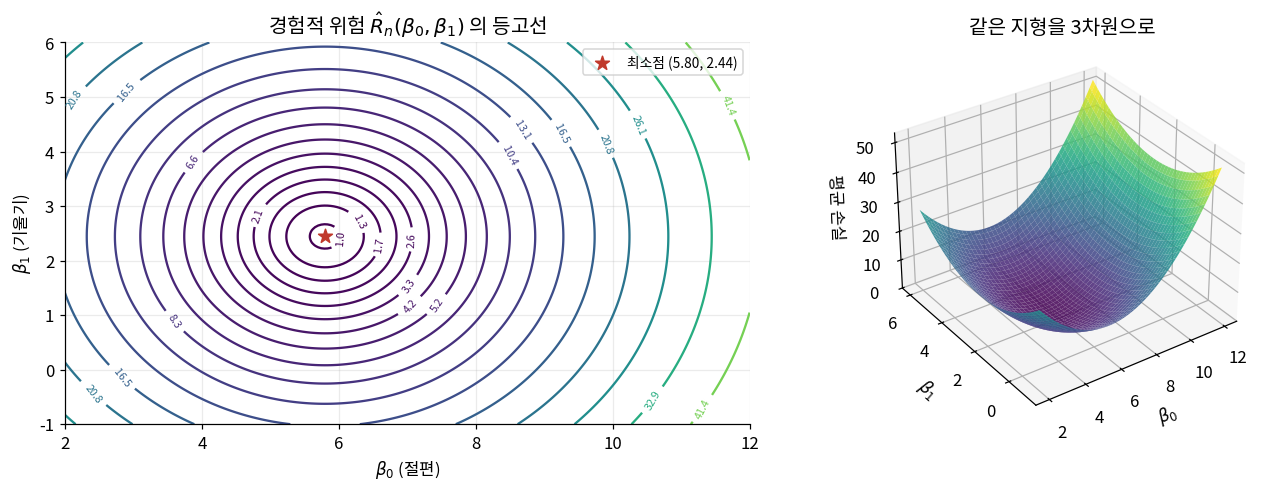

In [ ]:
xs, ys = sample_world(60, seed=7)
xz = (xs - xs.mean()) / xs.std()          # 표준화 (계산을 안정적으로 만드는 실무 관행)

b0s = np.linspace(2, 12, 220)
b1s = np.linspace(-1, 6, 220)
B0, B1 = np.meshgrid(b0s, b1s)
LOSS = np.array([[np.mean((ys - (b0 + b1 * xz)) ** 2) for b0 in b0s] for b1 in b1s])

# 정규방정식으로 구한 정확한 해
Xmat = np.c_[np.ones(len(xz)), xz]
beta_hat = np.linalg.solve(Xmat.T @ Xmat, Xmat.T @ ys)

fig = plt.figure(figsize=(13, 4.6))
ax1 = fig.add_subplot(1, 2, 1)
cs = ax1.contour(B0, B1, LOSS, levels=np.geomspace(LOSS.min() + .05, LOSS.max(), 18),
                 cmap="viridis")
ax1.clabel(cs, inline=True, fontsize=7, fmt="%.1f")
ax1.scatter(*beta_hat, color=C["red"], s=90, marker="*", zorder=5,
            label=f"최소점 ({beta_hat[0]:.2f}, {beta_hat[1]:.2f})")
ax1.set_xlabel("$\\beta_0$ (절편)"); ax1.set_ylabel("$\\beta_1$ (기울기)")
ax1.set_title("경험적 위험 $\\hat{R}_n(\\beta_0,\\beta_1)$ 의 등고선")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(B0, B1, LOSS, cmap="viridis", alpha=.85, linewidth=0, antialiased=True)
ax2.set_xlabel("$\\beta_0$"); ax2.set_ylabel("$\\beta_1$"); ax2.set_zlabel("평균 손실")
ax2.set_title("같은 지형을 3차원으로")
ax2.view_init(elev=32, azim=-125)
fig.tight_layout()
save(fig, "M11_loss_surface")
plt.show()

선형회귀 + 제곱손실의 지형은 **밥그릇 모양(볼록함수)** 이라 최소점이 하나뿐입니다.
그래서 공식 한 방으로 답이 나옵니다.

$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

반면 신경망의 손실 지형은 SL01 표지 그림처럼 봉우리와 골짜기가 여럿인 울퉁불퉁한 지형입니다.
그런 경우에는 공식이 없어서 **경사하강법**으로 조금씩 내려갑니다. 원리만 미리 보고 갑시다.

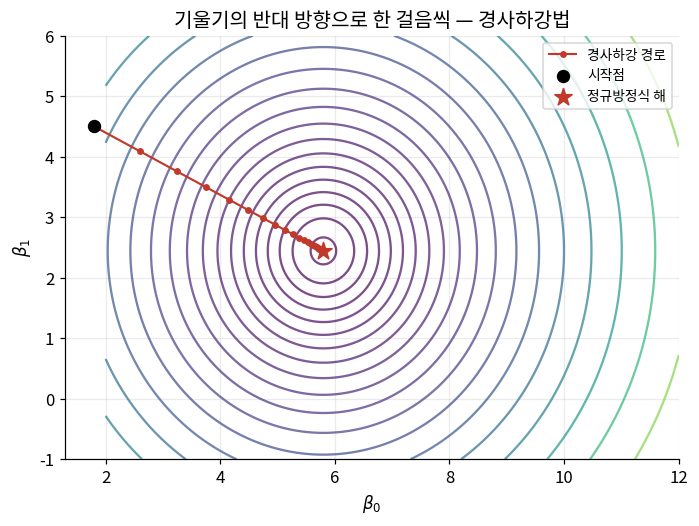

정규방정식 해 : β0=5.7994, β1=2.4434
경사하강 60회 : β0=5.7994, β1=2.4434


In [ ]:
def gradient_descent(X, y, lr=0.1, steps=60):
    beta = np.array([ys.mean() - 4.0, 4.5])      # 일부러 엉뚱한 곳에서 출발
    path = [beta.copy()]
    n = len(y)
    for _ in range(steps):
        grad = -2 / n * X.T @ (y - X @ beta)     # 평균제곱오차의 기울기
        beta = beta - lr * grad
        path.append(beta.copy())
    return np.array(path)


path = gradient_descent(Xmat, ys)

fig, ax = plt.subplots(figsize=(7.2, 5))
cs = ax.contour(B0, B1, LOSS, levels=np.geomspace(LOSS.min() + .05, LOSS.max(), 20),
                cmap="viridis", alpha=.7)
ax.plot(path[:, 0], path[:, 1], "o-", color=C["red"], ms=3.5, lw=1.4, label="경사하강 경로")
ax.scatter(*path[0], color="black", s=60, zorder=5, label="시작점")
ax.scatter(*beta_hat, color=C["red"], s=140, marker="*", zorder=5, label="정규방정식 해")
ax.set_xlabel("$\\beta_0$"); ax.set_ylabel("$\\beta_1$")
ax.set_title("기울기의 반대 방향으로 한 걸음씩 — 경사하강법")
ax.legend(fontsize=9)
save(fig, "M12_gradient_descent")
plt.show()

print(f"정규방정식 해 : β0={beta_hat[0]:.4f}, β1={beta_hat[1]:.4f}")
print(f"경사하강 60회 : β0={path[-1][0]:.4f}, β1={path[-1][1]:.4f}")

---
# 제3부 — 손으로 해보기

## 10. 선형회귀 실습 — 실제 데이터로 처음부터 끝까지

이제 진짜 데이터를 씁니다. scikit-learn에 들어 있는 **당뇨병 진행도 데이터**입니다.
환자 442명의 나이·성별·BMI·혈압·혈액검사 수치 10개로, 1년 뒤 질병 진행도를 예측하는 문제입니다.
(설명변수는 이미 표준화되어 있습니다.)

$$Y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p + \epsilon$$

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dia = load_diabetes(as_frame=True)
X_all, y_all = dia.data, dia.target

print("데이터 크기:", X_all.shape, " 목표변수:", y_all.name)
print("변수 목록:", list(X_all.columns))
X_all.head()

데이터 크기: (442, 10)  목표변수: target
변수 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### 10-1. 변수 하나로 시작 (단순선형회귀)

먼저 BMI 하나만 써서 $y = \beta_0 + \beta_1 \cdot \text{bmi}$ 를 맞춰 봅니다.
공식으로 직접 푼 값과 scikit-learn의 결과가 같은지 확인하는 것이 이 절의 목적입니다.

In [ ]:
x1 = X_all["bmi"].values
y1 = y_all.values

# (1) 정규방정식으로 직접 계산
Xd = np.c_[np.ones(len(x1)), x1]
beta_manual = np.linalg.solve(Xd.T @ Xd, Xd.T @ y1)

# (2) scikit-learn
lin = LinearRegression().fit(x1.reshape(-1, 1), y1)

print(f"직접 계산   : 절편 {beta_manual[0]:.3f}, 기울기 {beta_manual[1]:.3f}")
print(f"scikit-learn: 절편 {lin.intercept_:.3f}, 기울기 {lin.coef_[0]:.3f}")
print()
pred1 = Xd @ beta_manual
print(f"MSE  {mean_squared_error(y1, pred1):8.2f}")
print(f"RMSE {np.sqrt(mean_squared_error(y1, pred1)):8.2f}   ← 목표변수와 같은 단위라 해석하기 편함")
print(f"MAE  {mean_absolute_error(y1, pred1):8.2f}")
print(f"R²   {r2_score(y1, pred1):8.3f}   ← 분산의 몇 %를 설명했는가")

직접 계산   : 절편 152.133, 기울기 949.435
scikit-learn: 절편 152.133, 기울기 949.435

MSE   3890.46
RMSE    62.37   ← 목표변수와 같은 단위라 해석하기 편함
MAE     51.80
R²      0.344   ← 분산의 몇 %를 설명했는가


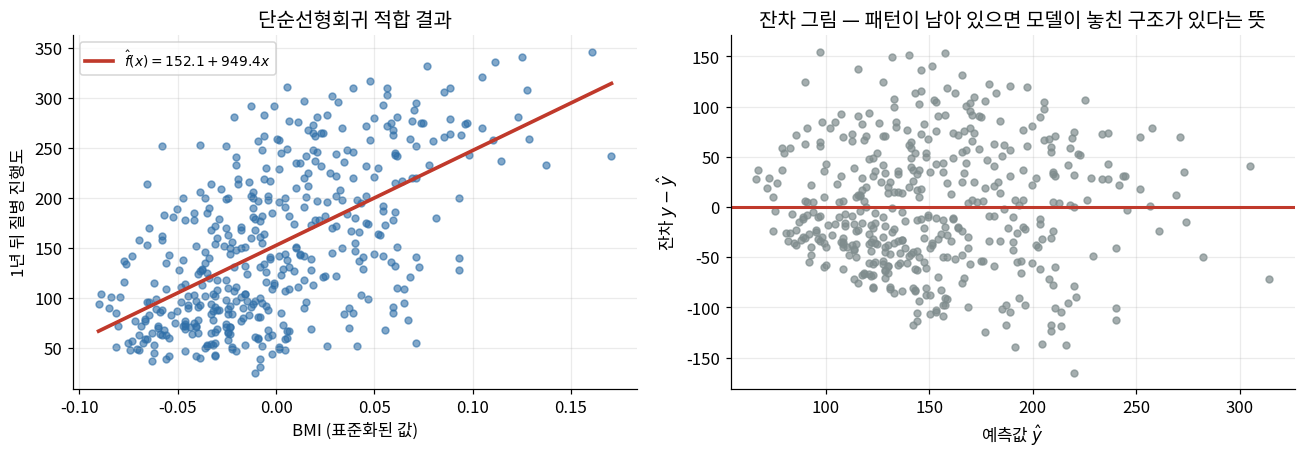

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
gx = np.linspace(x1.min(), x1.max(), 50)

axes[0].scatter(x1, y1, s=20, color=C["blue"], alpha=.6)
axes[0].plot(gx, beta_manual[0] + beta_manual[1] * gx, color=C["red"], lw=2.4,
             label=f"$\\hat{{f}}(x) = {beta_manual[0]:.1f} + {beta_manual[1]:.1f}x$")
axes[0].set_xlabel("BMI (표준화된 값)"); axes[0].set_ylabel("1년 뒤 질병 진행도")
axes[0].set_title("단순선형회귀 적합 결과"); axes[0].legend(fontsize=9)

resid = y1 - pred1
axes[1].scatter(pred1, resid, s=20, color=C["gray"], alpha=.7)
axes[1].axhline(0, color=C["red"], lw=2)
axes[1].set_xlabel("예측값 $\\hat{y}$"); axes[1].set_ylabel("잔차 $y - \\hat{y}$")
axes[1].set_title("잔차 그림 — 패턴이 남아 있으면 모델이 놓친 구조가 있다는 뜻")
fig.tight_layout()
save(fig, "M13_simple_regression")
plt.show()

R²가 0.34입니다. BMI 하나로는 진행도 변동의 3분의 1 정도만 설명된다는 뜻입니다.
잔차 그림에는 뚜렷한 곡선 패턴이 보이지 않으니, 적어도 "직선을 썼는데 사실은 곡선이었다"는 문제는 아닌 것 같습니다.
대신 잔차가 여전히 크게 퍼져 있습니다. 변수를 더 넣어 봅시다.

### 10-2. 변수를 모두 사용 (다중선형회귀) + 훈련/시험 분할

여기서 7장의 교훈을 적용합니다. **훈련에 쓴 데이터로 성능을 재지 않습니다.**

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=0)

rows = []
for name, cols in [("BMI 하나만", ["bmi"]),
                   ("BMI + 혈압", ["bmi", "bp"]),
                   ("BMI + 혈압 + s5", ["bmi", "bp", "s5"]),
                   ("변수 10개 전부", list(X_all.columns))]:
    m = LinearRegression().fit(X_tr[cols], y_tr)
    rows.append({
        "모델": name,
        "변수 수": len(cols),
        "훈련 RMSE": np.sqrt(mean_squared_error(y_tr, m.predict(X_tr[cols]))),
        "시험 RMSE": np.sqrt(mean_squared_error(y_te, m.predict(X_te[cols]))),
        "시험 R²": r2_score(y_te, m.predict(X_te[cols])),
    })

pd.DataFrame(rows).round(3)

,모델,변수 수,훈련 RMSE,시험 RMSE,시험 R²
0,BMI 하나만,1,62.392,62.621,0.231
1,BMI + 혈압,2,60.138,59.361,0.309
2,BMI + 혈압 + s5,3,55.046,56.991,0.363
3,변수 10개 전부,10,52.954,55.652,0.393


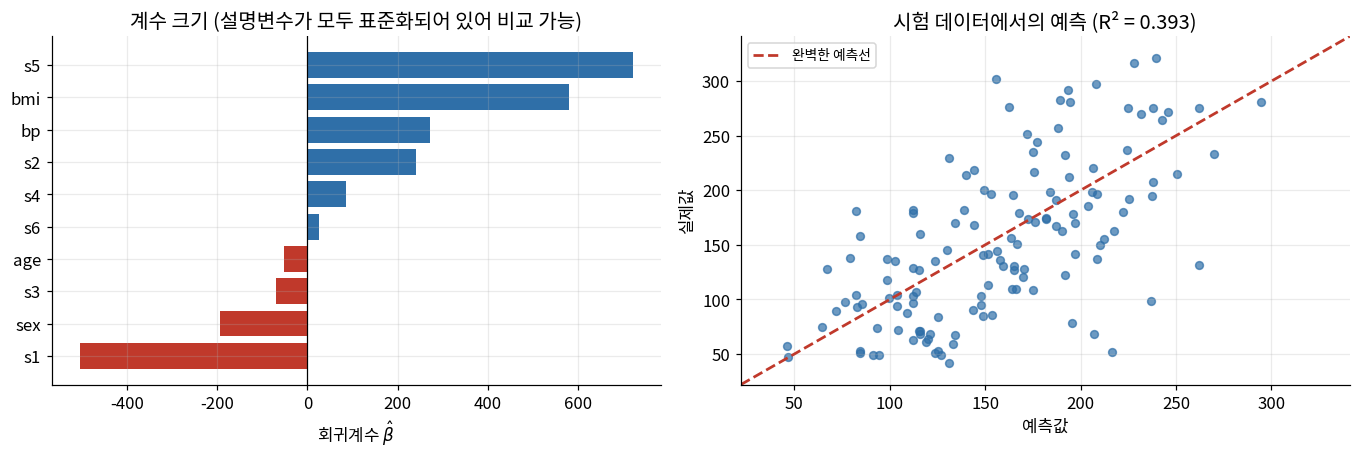

In [ ]:
full = LinearRegression().fit(X_tr, y_tr)
coef = pd.Series(full.coef_, index=X_all.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
colors = [C["red"] if v < 0 else C["blue"] for v in coef]
axes[0].barh(coef.index, coef.values, color=colors)
axes[0].axvline(0, color="black", lw=.8)
axes[0].set_xlabel("회귀계수 $\\hat{\\beta}$")
axes[0].set_title("계수 크기 (설명변수가 모두 표준화되어 있어 비교 가능)")

axes[1].scatter(full.predict(X_te), y_te, s=26, color=C["blue"], alpha=.7)
lims = [y_te.min() - 20, y_te.max() + 20]
axes[1].plot(lims, lims, color=C["red"], ls="--", lw=1.8, label="완벽한 예측선")
axes[1].set_xlim(*lims); axes[1].set_ylim(*lims)
axes[1].set_xlabel("예측값"); axes[1].set_ylabel("실제값")
axes[1].set_title(f"시험 데이터에서의 예측 (R² = {r2_score(y_te, full.predict(X_te)):.3f})")
axes[1].legend(fontsize=9)
fig.tight_layout()
save(fig, "M14_multiple_regression")
plt.show()

변수를 늘리니 시험 RMSE가 줄었습니다. 다만 무조건 좋아지지는 않습니다.
변수 10개짜리 모델은 훈련 RMSE와 시험 RMSE의 격차가 가장 큽니다. 12장에서 이 현상을 정면으로 다룹니다.

> **계수 해석 주의.** s1의 계수가 크게 음수라고 해서 "s1을 낮추면 병이 진행된다"고 읽으면 안 됩니다.
> 회귀계수는 "다른 변수를 고정했을 때의 연관"이지 인과가 아닙니다. 0교시 6장에서 본 그대로입니다.
> 게다가 서로 상관이 높은 변수들이 섞여 있으면(다중공선성) 계수의 부호까지 뒤집힐 수 있습니다.

## 11. 분류 실습 — 정답이 숫자가 아니라 라벨일 때

유방암 진단 데이터를 씁니다. 종양의 형태 특징 30개로 악성/양성을 맞히는 문제입니다.
먼저 **눈으로 보기 위해** 변수 두 개만 써서 결정 경계를 그려 봅니다.

데이터: (569, 30) | 클래스 비율: [0.37258348 0.62741652]


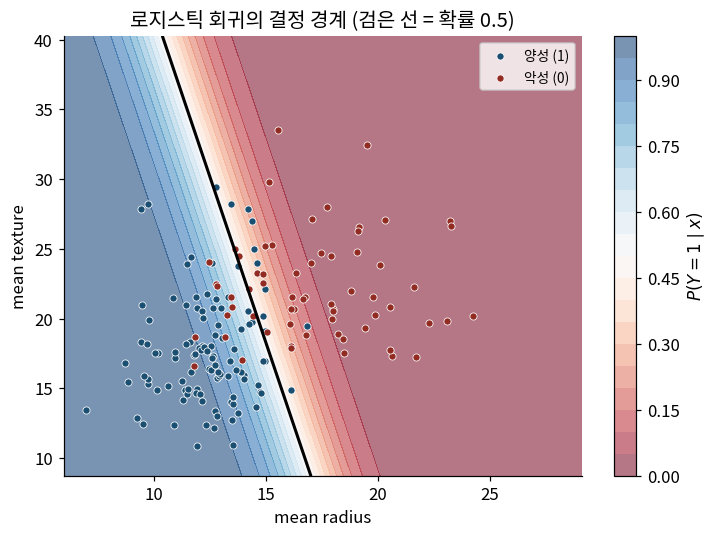

변수 2개 모델 정확도: 0.871


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

bc = load_breast_cancer(as_frame=True)
Xb, yb = bc.data, bc.target          # 1 = 양성(benign), 0 = 악성(malignant)
print("데이터:", Xb.shape, "| 클래스 비율:", np.bincount(yb) / len(yb))

two = ["mean radius", "mean texture"]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=.3, random_state=0, stratify=yb)

clf2 = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xb_tr[two], yb_tr)

xx, yy = np.meshgrid(np.linspace(Xb[two[0]].min() - 1, Xb[two[0]].max() + 1, 300),
                     np.linspace(Xb[two[1]].min() - 1, Xb[two[1]].max() + 1, 300))
prob = clf2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.6, 5.2))
cf = ax.contourf(xx, yy, prob, levels=20, cmap="RdBu", alpha=.55)
ax.contour(xx, yy, prob, levels=[0.5], colors="black", linewidths=2)
ax.scatter(Xb_te[two[0]][yb_te == 1], Xb_te[two[1]][yb_te == 1], s=22,
           color="#1B4F72", edgecolor="white", lw=.5, label="양성 (1)")
ax.scatter(Xb_te[two[0]][yb_te == 0], Xb_te[two[1]][yb_te == 0], s=22,
           color="#922B21", edgecolor="white", lw=.5, label="악성 (0)")
plt.colorbar(cf, ax=ax, label="$P(Y=1 \\mid x)$")
ax.set_xlabel(two[0]); ax.set_ylabel(two[1])
ax.set_title("로지스틱 회귀의 결정 경계 (검은 선 = 확률 0.5)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(False)
save(fig, "M15_decision_boundary")
plt.show()

print(f"변수 2개 모델 정확도: {accuracy_score(yb_te, clf2.predict(Xb_te[two])):.3f}")

8장에서 본 베이즈 분류기와 같은 구조입니다. 모델이 각 지점에서 $P(Y=1|x)$ 를 추정하고, 0.5를 넘으면 1로 예측합니다.
경계 근처의 점들은 애매한 사례이고, 여기서 틀리는 것은 어느 정도 불가피합니다.

이제 변수 30개를 다 써 봅시다.

정확도: 0.959

              precision    recall  f1-score   support

       악성(0)       0.94      0.95      0.95        64
       양성(1)       0.97      0.96      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



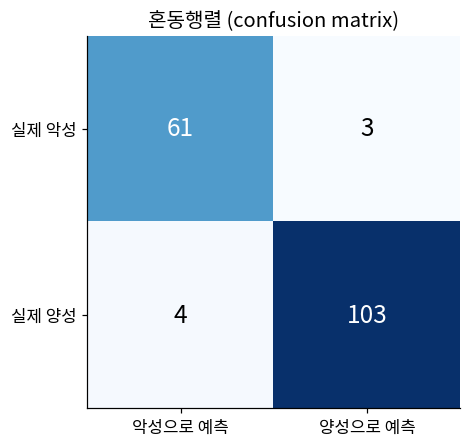

In [ ]:
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xb_tr, yb_tr)
pred = clf.predict(Xb_te)
cm = confusion_matrix(yb_te, pred)

print(f"정확도: {accuracy_score(yb_te, pred):.3f}\n")
print(classification_report(yb_te, pred, target_names=["악성(0)", "양성(1)"]))

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1], ["악성으로 예측", "양성으로 예측"])
ax.set_yticks([0, 1], ["실제 악성", "실제 양성"])
ax.set_title("혼동행렬 (confusion matrix)")
ax.grid(False)
save(fig, "M16_confusion_matrix")
plt.show()

정확도가 높게 나왔습니다. 그런데 **정확도 하나만 보고 좋아하면 안 되는 이유**가 두 가지 있습니다.

첫째, 클래스가 불균형하면 정확도는 쉽게 속습니다.
전체의 99%가 정상인 데이터에서 "무조건 정상"이라고 답하는 모델도 정확도 99%를 받습니다.

둘째, 틀리는 방향마다 비용이 다릅니다.
악성 종양을 양성으로 잘못 판단하는 것과 그 반대는 결코 같은 무게가 아닙니다.
혼동행렬을 보는 이유가 여기 있고, 정밀도·재현율 같은 지표가 따로 있는 이유이기도 합니다.

In [ ]:
# 불균형 데이터에서 정확도가 얼마나 무의미해질 수 있는지
n_imb = 10000
y_imb = (rng.random(n_imb) < 0.01).astype(int)     # 1% 만 양성
always_zero = np.zeros(n_imb, dtype=int)

print(f"'무조건 0으로 예측하는 모델'의 정확도 : {accuracy_score(y_imb, always_zero):.3f}")
print(f"실제로 잡아낸 양성 건수              : {int(((always_zero == 1) & (y_imb == 1)).sum())} / {int(y_imb.sum())}")

'무조건 0으로 예측하는 모델'의 정확도 : 0.990
실제로 잡아낸 양성 건수              : 0 / 99


### 왜 0-1 손실을 직접 최소화하지 않는가

분류의 진짜 목표는 오분류를 줄이는 것, 즉 0-1 손실입니다.
그런데 실제 알고리즘은 로지스틱 손실이나 힌지 손실 같은 **대체 손실(surrogate loss)** 을 최소화합니다.
이유는 그림 하나로 설명됩니다.

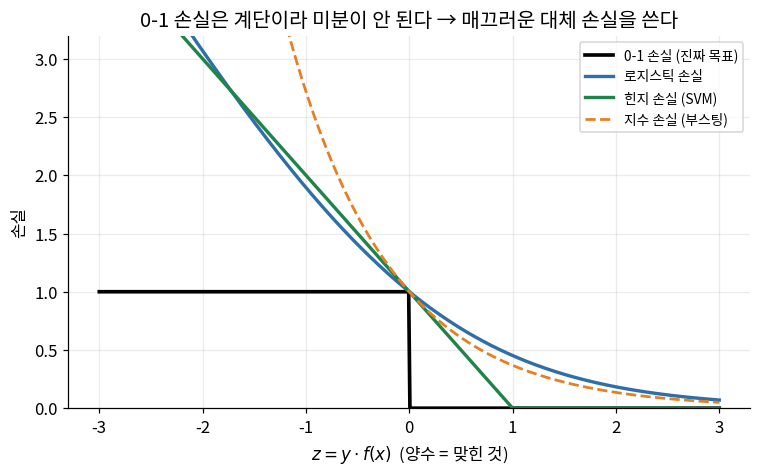

In [ ]:
z = np.linspace(-3, 3, 500)          # z = y·f(x), 양수면 맞힌 것

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(z, (z < 0).astype(float), color="black", lw=2.4, label="0-1 손실 (진짜 목표)")
ax.plot(z, np.log(1 + np.exp(-z)) / np.log(2), color=C["blue"], lw=2.2, label="로지스틱 손실")
ax.plot(z, np.maximum(0, 1 - z), color=C["green"], lw=2.2, label="힌지 손실 (SVM)")
ax.plot(z, np.exp(-z), color=C["orange"], lw=1.8, ls="--", label="지수 손실 (부스팅)")
ax.set_ylim(0, 3.2); ax.set_xlabel("$z = y \\cdot f(x)$  (양수 = 맞힌 것)")
ax.set_ylabel("손실"); ax.legend(fontsize=9)
ax.set_title("0-1 손실은 계단이라 미분이 안 된다 → 매끄러운 대체 손실을 쓴다")
save(fig, "M17_surrogate_loss")
plt.show()

검은 계단 함수는 기울기가 0 아니면 정의되지 않습니다. 경사하강법이 내려갈 방향을 찾을 수가 없습니다.
그래서 위쪽에서 계단을 덮는 매끄러운 곡선을 대신 최소화합니다.
로지스틱 회귀, SVM, 부스팅의 차이는 결국 **어떤 대체 손실을 골랐느냐**의 차이입니다.

## 12. 함수공간 $\mathcal{F}$ 와 과적합

ERM의 두 번째 타협을 기억합니까? 모든 함수가 아니라 제한된 공간 $\mathcal{F}$ 안에서만 찾는다는 것이었습니다.
그럼 $\mathcal{F}$ 를 넓히면 넓힐수록 좋을까요? 다항식 차수를 1부터 15까지 올려 보면 답이 나옵니다.

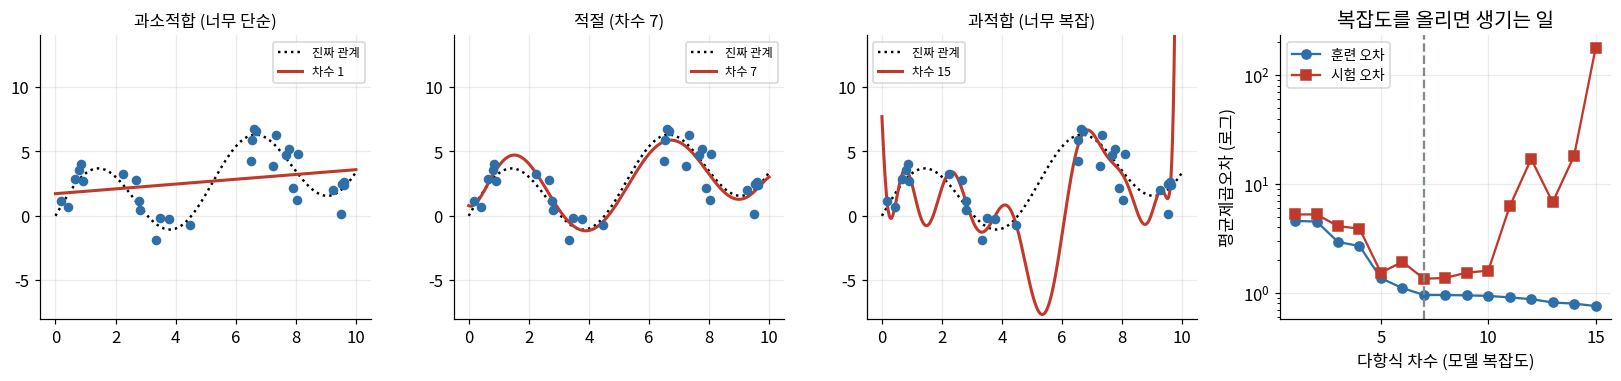

시험 오차가 가장 작은 차수: 7


In [ ]:
def wave(x):
    return np.sin(1.2 * x) * 3 + 0.5 * x


n_tr = 30
x_tr = np.sort(rng.uniform(0, 10, n_tr))
y_tr_ = wave(x_tr) + rng.normal(0, 1.0, n_tr)
x_te = np.sort(rng.uniform(0, 10, 500))
y_te_ = wave(x_te) + rng.normal(0, 1.0, 500)

degrees = range(1, 16)
tr_err, te_err = [], []
for d in degrees:
    c = np.polyfit(x_tr, y_tr_, d)
    tr_err.append(np.mean((y_tr_ - np.polyval(c, x_tr)) ** 2))
    te_err.append(np.mean((y_te_ - np.polyval(c, x_te)) ** 2))

best = int(np.argmin(te_err)) + 1
gx = np.linspace(0, 10, 400)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, d, title in zip(axes[:3], [1, best, 15],
                        ["과소적합 (너무 단순)", f"적절 (차수 {best})", "과적합 (너무 복잡)"]):
    c = np.polyfit(x_tr, y_tr_, d)
    ax.scatter(x_tr, y_tr_, s=28, color=C["blue"], zorder=3)
    ax.plot(gx, wave(gx), color="black", ls=":", lw=1.6, label="진짜 관계")
    ax.plot(gx, np.polyval(c, gx), color=C["red"], lw=2, label=f"차수 {d}")
    ax.set_ylim(-8, 14); ax.set_title(title, fontsize=11); ax.legend(fontsize=8)

axes[3].plot(list(degrees), tr_err, "o-", color=C["blue"], label="훈련 오차")
axes[3].plot(list(degrees), te_err, "s-", color=C["red"], label="시험 오차")
axes[3].axvline(best, color=C["gray"], ls="--")
axes[3].set_yscale("log"); axes[3].set_xlabel("다항식 차수 (모델 복잡도)")
axes[3].set_ylabel("평균제곱오차 (로그)"); axes[3].legend(fontsize=9)
axes[3].set_title("복잡도를 올리면 생기는 일")
fig.tight_layout()
save(fig, "M18_overfitting")
plt.show()

print(f"시험 오차가 가장 작은 차수: {best}")

훈련 오차는 차수를 올릴수록 계속 내려갑니다. 시험 오차는 어느 지점까지 내려갔다가 다시 치솟습니다.
이 U자 곡선이 머신러닝에서 가장 자주 보게 될 그림입니다.

왜 이런 일이 생기는지 한 번 더 들여다봅시다. 같은 조건에서 데이터만 새로 뽑아 여러 번 학습시켜 보면 성격이 드러납니다.

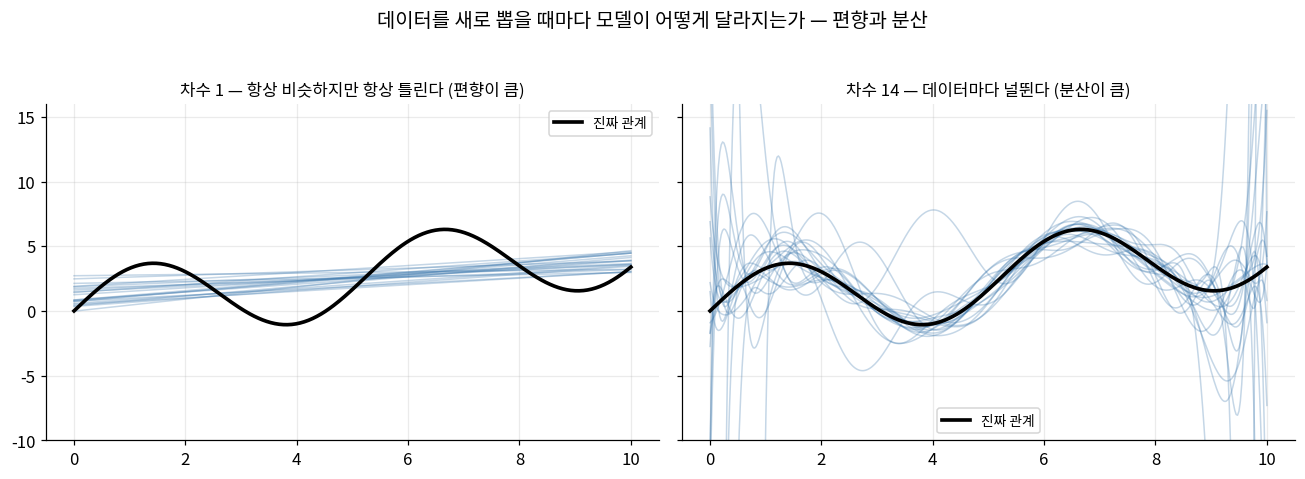

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, d, title in zip(axes, [1, 14], ["차수 1 — 항상 비슷하지만 항상 틀린다 (편향이 큼)",
                                        "차수 14 — 데이터마다 널뛴다 (분산이 큼)"]):
    for _ in range(20):
        xs_ = np.sort(rng.uniform(0, 10, 30))
        ys_ = wave(xs_) + rng.normal(0, 1.0, 30)
        c = np.polyfit(xs_, ys_, d)
        ax.plot(gx, np.polyval(c, gx), color=C["blue"], alpha=.28, lw=1)
    ax.plot(gx, wave(gx), color="black", lw=2.4, label="진짜 관계")
    ax.set_ylim(-10, 16); ax.set_title(title, fontsize=11); ax.legend(fontsize=9)
fig.suptitle("데이터를 새로 뽑을 때마다 모델이 어떻게 달라지는가 — 편향과 분산", y=1.03, fontsize=13)
fig.tight_layout()
save(fig, "M19_bias_variance")
plt.show()

단순한 모델은 데이터가 바뀌어도 결과가 안정적이지만 진짜 관계에서 늘 벗어나 있습니다(**편향**).
복잡한 모델은 평균적으로는 진짜 관계 근처에 있지만 데이터마다 요동칩니다(**분산**).

$$\text{예측 오차} \;=\; \text{편향}^2 \;+\; \text{분산} \;+\; \text{줄일 수 없는 오차}$$

$\mathcal{F}$ 를 고르는 일은 결국 이 둘 사이에서 균형점을 찾는 일입니다.
그 균형점을 데이터로 찾는 방법이 **교차검증**이고, 다음 시간부터 본격적으로 다룹니다.